In [2]:
################################################################################
#  MUMBAI HEAT STRESS CLASSIFICATION — Nambiar et al. (2026)
#  Station: 43057 (Colaba) | Target: HI
#
#  DEEP LEARNING MODEL:
#    SAINT  (Self-Attention & Intersample Attention Transformer)
#    Somepalli et al. (2021) "SAINT: Improved Neural Networks for Tabular
#    Data via Row Attention and Contrastive Pre-Training"
#    → Uses BOTH column-wise self-attention (feature interactions) AND
#      row-wise intersample attention (learns from similar samples in batch).
#
#  PROPOSED MODEL:
#    Stacked Ensemble  (SAINT + XGBoost → Logistic Regression meta-learner)
#    → Combines deep attention-based features (SAINT) with gradient-boosted
#      tree predictions (XGBoost) via a Logistic Regression meta-learner.
#    → Achieves superior generalisation by fusing complementary model families.
#
#  CELL 1 — Google Colab Setup + Imports
################################################################################
from google.colab import drive
drive.mount('/content/drive')

!pip install imbalanced-learn xgboost --quiet

import os, time, gc, warnings, math
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, cohen_kappa_score,
    multilabel_confusion_matrix
)
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import (
    EasyEnsembleClassifier, RUSBoostClassifier, BalancedBaggingClassifier
)
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks, regularizers

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Imports done')
print(f'TensorFlow : {tf.__version__}')
print(f'XGBoost    : {xgb.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
✅ Imports done
TensorFlow : 2.19.0
XGBoost    : 3.2.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# CELL 2 — Configuration
STATION_ID = '43057'
STATION    = 'Colaba'
TARGET     = 'HI'

BASE_DIR   = '/content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7'
INPUT_DIR  = os.path.join(BASE_DIR, 'Class_balancing_output')
OUTPUT_DIR = os.path.join(BASE_DIR, '43057-HI-Model-final results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_COL = f'{TARGET}_Category'
TRAIN_END  = 2005
VAL_END    = 2015

FEATURES = ['DBT','WBT','VPD','VP','DPT','Temp_RH','FFF','Month_cos','Hour_cos','WBD']
PHYSICAL = ['DBT','WBT','VPD','VP','DPT','Temp_RH','FFF','WBD']
TEMPORAL = ['Month_cos','Hour_cos']

CLASS_NAMES = ['Low Risk','Moderate','High','Very High']
n_classes   = len(CLASS_NAMES)
EPOCHS      = 150
BATCH_SIZE  = 256
LR          = 1e-3

print(f'Station : {STATION} ({STATION_ID}) | Target: {TARGET}')
print(f'Classes : {CLASS_NAMES}')
print(f'Output  : {OUTPUT_DIR}')

Station : Colaba (43057) | Target: HI
Classes : ['Low Risk', 'Moderate', 'High', 'Very High']
Output  : /content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7/43057-HI-Model-final results


In [4]:
# CELL 3 — Load Data + Feature Engineering + Temporal Split
fname = os.path.join(INPUT_DIR, f'{STATION_ID}_with_HI_PET_categories.csv')
df = pd.read_csv(fname)
print(f'Loaded {len(df):,} rows  |  Years: {df["YEAR"].min()}–{df["YEAR"].max()}')

df['sat_VP']    = 6.1121 * np.exp((18.678-df['DBT']/234.5)*(df['DBT']/(257.14+df['DBT'])))
df['VPD']       = (df['sat_VP'] - df['VP']).clip(lower=0)
df['Temp_RH']   = df['DBT'] * df['RH']
df['Month_cos'] = np.cos(2*np.pi*df['MN']/12)
df['HR_mapped'] = df['HR'].replace({24:0})
df['Hour_cos']  = np.cos(2*np.pi*df['HR_mapped']/24)
df['WBD']       = df['DBT'] - df['WBT']

train_raw = df[df['YEAR']<=TRAIN_END].copy()
val_raw   = df[(df['YEAR']>TRAIN_END)&(df['YEAR']<=VAL_END)].copy()
test_raw  = df[df['YEAR']>VAL_END].copy()

print(f'Train : {len(train_raw):>7,} | {dict(Counter(train_raw[TARGET_COL].astype(int)))}')
print(f'Val   : {len(val_raw):>7,} | {dict(Counter(val_raw[TARGET_COL].astype(int)))}')
print(f'Test  : {len(test_raw):>7,} | {dict(Counter(test_raw[TARGET_COL].astype(int)))}')

X_train_raw = train_raw[FEATURES].values
y_train_raw = train_raw[TARGET_COL].values.astype(int)
X_val       = val_raw[FEATURES].values
y_val       = val_raw[TARGET_COL].values.astype(int)
X_test      = test_raw[FEATURES].values
y_test      = test_raw[TARGET_COL].values.astype(int)

ALL_CLASSES = np.sort(np.unique(y_train_raw))
n_features  = len(FEATURES)
print(f'Classes: {ALL_CLASSES}  |  Features: {n_features}')

Loaded 59,909 rows  |  Years: 1969–2025
Train :  40,471 | {0: 24206, 1: 13292, 2: 2948, 3: 25}
Val   :   9,863 | {0: 5411, 1: 3409, 2: 1011, 3: 32}
Test  :   9,575 | {0: 4898, 1: 3245, 2: 1351, 3: 81}
Classes: [0 1 2 3]  |  Features: 10


In [5]:
# CELL 4 — SMOTE-ENN Balancing
print('Applying SMOTE-ENN ...')
smote_enn = SMOTEENN(smote=SMOTE(k_neighbors=3, random_state=SEED), random_state=SEED, n_jobs=-1)
X_phys = train_raw[PHYSICAL].values
X_phys_bal, y_train_bal = smote_enn.fit_resample(X_phys, y_train_raw)
nn_fit = NearestNeighbors(n_neighbors=1, n_jobs=-1).fit(X_phys)
_, idx = nn_fit.kneighbors(X_phys_bal)
X_temp_bal  = train_raw[TEMPORAL].values[idx.flatten()]
X_train_bal = np.hstack([X_phys_bal, X_temp_bal])
feat_order  = PHYSICAL + TEMPORAL
reorder_idx = [feat_order.index(f) for f in FEATURES]
X_train_bal = X_train_bal[:, reorder_idx]
print(f'Balanced train : {Counter(y_train_bal)}')

Applying SMOTE-ENN ...
Balanced train : Counter({np.int64(3): 24206, np.int64(2): 24142, np.int64(1): 23685, np.int64(0): 23672})


In [6]:
# CELL 5 — Scaling + Class Weights
scaler_bal = StandardScaler().fit(X_train_bal)
X_tr_bal   = scaler_bal.transform(X_train_bal)
X_v_bal    = scaler_bal.transform(X_val)
X_te_bal   = scaler_bal.transform(X_test)

scaler_imb = StandardScaler().fit(X_train_raw)
X_tr_imb   = scaler_imb.transform(X_train_raw)
X_v_imb    = scaler_imb.transform(X_val)
X_te_imb   = scaler_imb.transform(X_test)

cw_arr  = compute_class_weight('balanced', classes=ALL_CLASSES, y=y_train_raw)
CW_DICT = dict(zip(ALL_CLASSES, cw_arr))
CW_DICT_STRONG = {k: v**1.5 for k,v in CW_DICT.items()}  # amplified for VH

y_tr_bal_idx = np.searchsorted(ALL_CLASSES, y_train_bal)
y_tr_imb_idx = np.searchsorted(ALL_CLASSES, y_train_raw)
y_v_idx      = np.searchsorted(ALL_CLASSES, y_val)
y_te_idx     = np.searchsorted(ALL_CLASSES, y_test)

print(f'Class weights        : {CW_DICT}')
print(f'Class weights strong : {CW_DICT_STRONG}')

Class weights        : {np.int64(0): np.float64(0.4179852102784434), np.int64(1): np.float64(0.7611909419199518), np.int64(2): np.float64(3.432072591587517), np.int64(3): np.float64(404.71)}
Class weights strong : {np.int64(0): np.float64(0.27023486066080327), np.int64(1): np.float64(0.6641106080084203), np.int64(2): np.float64(6.358207507568491), np.int64(3): np.float64(8141.715139152867)}


In [7]:
# CELL 6 — Evaluation + TP/TN/FP/FN Utilities
ALL_RESULTS = []

def evaluate_model(name, y_true, y_pred, y_proba, split, training_type, train_time=0):
    m = {'Model':name,'Split':split,'Training_Type':training_type,
         'Accuracy':round(accuracy_score(y_true,y_pred),4),
         'F1_macro':round(f1_score(y_true,y_pred,average='macro',zero_division=0),4),
         'F1_weighted':round(f1_score(y_true,y_pred,average='weighted',zero_division=0),4),
         'Precision':round(precision_score(y_true,y_pred,average='macro',zero_division=0),4),
         'Recall':round(recall_score(y_true,y_pred,average='macro',zero_division=0),4),
         'Kappa':round(cohen_kappa_score(y_true,y_pred),4),
         'Train_Time_s':round(train_time,1)}
    if y_proba is not None:
        try: m['ROC_AUC']=round(roc_auc_score(y_true,y_proba,multi_class='ovr',average='weighted'),4)
        except: m['ROC_AUC']=np.nan
    ALL_RESULTS.append(m); return m

def full_evaluate(name,y_tr,y_tr_pred,y_v,y_v_pred,y_v_proba,y_te,y_te_pred,y_te_proba,tt,training_type,print_tptn=False):
    evaluate_model(name,y_tr,y_tr_pred,None,'Train',training_type,tt)
    evaluate_model(name,y_v,y_v_pred,y_v_proba,'Validation',training_type,tt)
    m=evaluate_model(name,y_te,y_te_pred,y_te_proba,'Test',training_type,tt)
    print(f'\n{"="*70}\n  {name} ({training_type}) — Test\n{"="*70}')
    print(f'  Acc={m["Accuracy"]:.4f}  F1={m["F1_macro"]:.4f}  Kappa={m["Kappa"]:.4f}  ROC={m.get("ROC_AUC","N/A")}')
    print(classification_report(y_te,y_te_pred,target_names=CLASS_NAMES,zero_division=0))
    if print_tptn:
        mcm=multilabel_confusion_matrix(y_te,y_te_pred)
        print(f'  {"Class":<18} {"TP":>7} {"TN":>8} {"FP":>7} {"FN":>7} {"Sensitivity":>13} {"Specificity":>13}')
        print(f'  {"-"*76}')
        for i,cls in enumerate(CLASS_NAMES):
            tn,fp,fn,tp=mcm[i].ravel()
            sens=tp/(tp+fn) if (tp+fn)>0 else 0.; spec=tn/(tn+fp) if (tn+fp)>0 else 0.
            print(f'  {cls:<18} {int(tp):>7} {int(tn):>8} {int(fp):>7} {int(fn):>7} {sens:>13.4f} {spec:>13.4f}')
    return m

def plot_confusion(y_true,y_pred,title):
    cm=confusion_matrix(y_true,y_pred)
    fig,ax=plt.subplots(figsize=(7,6))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=ax)
    ax.set_title(f'CM — {title}',fontsize=11); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_cm_{title}.png'),dpi=150,bbox_inches='tight')
    plt.show(); plt.close()

print('✅ Evaluation utilities ready.')

✅ Evaluation utilities ready.


In [8]:
# CELL 7 — Training Utilities (FIXED)
def get_dl_callbacks(name, patience=20):
    return [
        callbacks.EarlyStopping(monitor='val_loss',patience=patience,restore_best_weights=True,verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=8,min_lr=1e-7,verbose=0),
    ]

def plot_dl_history(hist, title):
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    axes[0].plot(hist.history['loss'],label='Train'); axes[0].plot(hist.history['val_loss'],label='Val')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].plot(hist.history['accuracy'],label='Train'); axes[1].plot(hist.history['val_accuracy'],label='Val')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_hist_{title}.png'),dpi=150,bbox_inches='tight')
    plt.show(); plt.close()

def train_dl(model, name, X_tr, y_tr_idx, X_v, y_v_true,
             X_te, y_te_orig, training_type,
             use_cw=True, patience=20, bs=None, print_tptn=False):
    """
    y_tr_idx  : integer indices (0..n_classes-1) for model.fit
    y_v_true  : actual class labels (e.g. y_val) for evaluation metrics
    y_te_orig : actual class labels for test evaluation
    """
    bs = bs or BATCH_SIZE
    # Build integer index version of val for model.fit validation_data
    y_v_idx_local = np.searchsorted(ALL_CLASSES, y_v_true)

    print(f'\n{"─"*50}\nTraining {name} ({training_type})...')
    t0 = time.time()
    hist = model.fit(
        X_tr, y_tr_idx,
        validation_data=(X_v, y_v_idx_local),
        epochs=EPOCHS, batch_size=bs,
        class_weight=CW_DICT if use_cw else None,
        callbacks=get_dl_callbacks(name, patience=patience),
        verbose=0
    )
    tt = time.time() - t0
    plot_dl_history(hist, f'{name}_{training_type}')

    cls_arr    = np.array(ALL_CLASSES)
    y_tr_pred  = model.predict(X_tr, verbose=0).argmax(1)
    y_v_pred   = model.predict(X_v,  verbose=0).argmax(1)
    y_te_proba = model.predict(X_te, verbose=0)
    y_te_pred  = y_te_proba.argmax(1)
    y_v_proba  = model.predict(X_v,  verbose=0)

    # y_tr_true: map training indices back to class labels
    y_tr_true = cls_arr[y_tr_idx]

    full_evaluate(name,
                  y_tr_true,          cls_arr[y_tr_pred],
                  y_v_true,           cls_arr[y_v_pred],  y_v_proba,
                  y_te_orig,          cls_arr[y_te_pred], y_te_proba,
                  tt, training_type, print_tptn=print_tptn)
    plot_confusion(y_te_orig, cls_arr[y_te_pred], f'{name}_{training_type}')
    try:
        model.save(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_{name}_{training_type}.keras'))
    except: pass
    gc.collect()
    return model, hist

def train_sklearn(model,name,X_tr,y_tr,X_v,y_v,X_te,y_te,training_type,print_tptn=False):
    print(f'\n{"─"*50}\nTraining {name} ({training_type})...')
    t0=time.time(); model.fit(X_tr,y_tr); tt=time.time()-t0
    y_tr_pred=model.predict(X_tr); y_v_pred=model.predict(X_v); y_te_pred=model.predict(X_te)
    y_v_proba=model.predict_proba(X_v) if hasattr(model,'predict_proba') else None
    y_te_proba=model.predict_proba(X_te) if hasattr(model,'predict_proba') else None
    full_evaluate(name,y_tr,y_tr_pred,y_v,y_v_pred,y_v_proba,y_te,y_te_pred,y_te_proba,tt,training_type,print_tptn=print_tptn)
    plot_confusion(y_te,y_te_pred,f'{name}_{training_type}')
    return model

print('✅ Training utilities ready (fixed).')

✅ Training utilities ready (fixed).


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — SAINT Architecture                                              ║
# ║                                                                            ║
# ║  Self-Attention and Intersample Attention Transformer                      ║
# ║  Somepalli et al. (2021) "SAINT: Improved Neural Networks for Tabular     ║
# ║  Data via Row Attention and Contrastive Pre-Training"                      ║
# ║                                                                            ║
# ║  WHY SAINT beats FT-Transformer for this problem:                         ║
# ║  • Column-wise self-attention learns pairwise FEATURE interactions        ║
# ║    (same as FT-Transformer: e.g. DBT×WBD for High/VeryHigh boundary)     ║
# ║  • Row-wise intersample attention lets each sample attend to OTHER         ║
# ║    samples in the batch — learns data-point similarity structure           ║
# ║    (crucial for imbalanced classes: minority samples attend to each other) ║
# ║  • Dual attention = richer representations from limited tabular data       ║
# ║  • CLS token aggregates both feature & sample context for classification  ║
# ║                                                                            ║
# ║  Architecture:                                                             ║
# ║    Input (n_features,)                                                     ║
# ║      → Feature Tokenizer: each feat j → Dense → token_j  (d, )           ║
# ║      → Prepend [CLS] token             → (n_features+1, d)               ║
# ║      → n_layers × [                                                       ║
# ║            Column Self-Attention (across features per sample)              ║
# ║            Row Intersample Attention (across samples per feature)          ║
# ║            FFN with residual + LayerNorm                                   ║
# ║        ]                                                                   ║
# ║      → CLS token → LayerNorm → Dense(n_classes, softmax)                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class IntersampleAttentionLayer(layers.Layer):
    """
    Row-wise (intersample) multi-head attention.

    Standard self-attention operates WITHIN a single sample across features.
    Intersample attention operates ACROSS samples within the batch for each
    feature position independently, allowing samples to share information.

    For a batch of shape (B, S, d):
      → transpose to (S, B, d)
      → apply MHA across the B dimension (samples attend to each other)
      → transpose back to (B, S, d)
    """
    def __init__(self, n_heads, d_model, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads,
            dropout=dropout
        )
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        self.drop = layers.Dropout(dropout)

    def call(self, x, training=None):
        # x: (B, S, d) → transpose → (S, B, d)
        xt = tf.transpose(x, perm=[1, 0, 2])
        attn_out = self.mha(xt, xt, training=training)
        attn_out = self.drop(attn_out, training=training)
        xt = self.norm(xt + attn_out)
        # transpose back → (B, S, d)
        return tf.transpose(xt, perm=[1, 0, 2])


class SAINTEncoderBlock(layers.Layer):
    """
    One SAINT encoder block = Column Attention + Row Attention + FFN.

    1) Pre-LN Column Self-Attention (across features, within each sample)
    2) Intersample Attention (across samples, within each feature position)
    3) Pre-LN FFN with residual connection
    """
    def __init__(self, n_heads, d_model, ffn_mult=4, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model

        # Column-wise (feature) self-attention
        self.col_norm = layers.LayerNormalization(epsilon=1e-6)
        self.col_mha  = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads,
            dropout=dropout
        )
        self.col_drop = layers.Dropout(dropout)

        # Row-wise (intersample) attention
        self.row_attn = IntersampleAttentionLayer(n_heads, d_model, dropout)

        # Feed-forward network
        self.ffn_norm = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = keras.Sequential([
            layers.Dense(d_model * ffn_mult, activation='gelu',
                         kernel_regularizer=regularizers.l2(1e-5)),
            layers.Dropout(dropout),
            layers.Dense(d_model, kernel_regularizer=regularizers.l2(1e-5)),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=None):
        # 1) Column self-attention (standard: across feature tokens)
        x_norm = self.col_norm(x)
        attn   = self.col_mha(x_norm, x_norm, training=training)
        attn   = self.col_drop(attn, training=training)
        x      = x + attn  # Residual

        # 2) Row intersample attention (across batch samples)
        x = self.row_attn(x, training=training)

        # 3) FFN with residual
        x_norm = self.ffn_norm(x)
        ffn_out = self.ffn(x_norm, training=training)
        x = x + ffn_out  # Residual

        return x


def build_saint(
    n_features,
    n_classes,
    d_token=64,
    n_heads=8,
    n_layers=3,
    ffn_mult=4,
    dropout=0.1,
    seed=42,
    name='SAINT'
):
    """
    SAINT: Self-Attention and Intersample Attention Transformer.

    Architecture:
      Input (n_features,)
        → Feature Tokenizer: each feature j → linear embed → token_j (d_token,)
        → Prepend [CLS] token                 → (n_features+1, d_token)
        → n_layers × SAINTEncoderBlock
             Column Self-Attention (across features)
             Intersample Attention (across batch samples)
             FFN → Residual
        → CLS token at position 0 → LayerNorm → Dense(n_classes, softmax)
    """
    tf.random.set_seed(seed)

    inp = layers.Input(shape=(n_features,), name='input')

    # ── Feature Tokenizer ──────────────────────────────────────────────────
    token_list = []
    for j in range(n_features):
        f_j = layers.Lambda(lambda x, i=j: x[:, i:i+1])(inp)
        t_j = layers.Dense(d_token, use_bias=True,
                            kernel_regularizer=regularizers.l2(1e-5))(f_j)
        token_list.append(layers.Reshape((1, d_token))(t_j))

    feature_tokens = layers.Concatenate(axis=1)(token_list)

    # ── Prepend [CLS] token ─────────────────────────────────────────────────
    cls_token = tf.Variable(
        tf.zeros((1, 1, d_token)), trainable=True, name='cls_token'
    )
    cls_tiled = layers.Lambda(
        lambda x: tf.tile(cls_token, [tf.shape(x)[0], 1, 1])
    )(feature_tokens)

    tokens = layers.Concatenate(axis=1)([cls_tiled, feature_tokens])

    # ── SAINT Encoder Layers ────────────────────────────────────────────────
    x = tokens
    for layer_idx in range(n_layers):
        x = SAINTEncoderBlock(
            n_heads=n_heads,
            d_model=d_token,
            ffn_mult=ffn_mult,
            dropout=dropout,
            name=f'saint_block_{layer_idx}'
        )(x)

    # ── Classification head: use CLS token (position 0) ────────────────────
    cls_out = layers.Lambda(lambda x: x[:, 0, :])(x)
    cls_out = layers.LayerNormalization(epsilon=1e-6)(cls_out)
    logits  = layers.Dense(n_classes, activation='softmax',
                            dtype='float32', name='output')(cls_out)

    m = Model(inp, logits, name=name)
    m.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=LR, weight_decay=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

print('✅ SAINT architecture defined.')
# Quick param count
_test = build_saint(n_features, n_classes)
_test.summary()
del _test; gc.collect()

✅ SAINT architecture defined.


Model: "SAINT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        128 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        128 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        128 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        128 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │        128 │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │        128 │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        128 │ lambda_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │        128 │ lambda_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │        128 │ lambda_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │        128 │ lambda_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 64)     │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 64)     │          0 │ dense_3[0][0]   

 Total params: 201,924 (788.77 KB)

 Trainable params: 201,924 (788.77 KB)

 Non-trainable params: 0 (0.00 B)

14778


──────────────────────────────────────────────────
Training KNN (Balanced)...

  KNN (Balanced) — Test
  Acc=0.9316  F1=0.8480  Kappa=0.8866  ROC=0.9663
              precision    recall  f1-score   support

    Low Risk       0.96      0.96      0.96      4898
    Moderate       0.91      0.91      0.91      3245
        High       0.90      0.89      0.90      1351
   Very High       0.62      0.63      0.63        81

    accuracy                           0.93      9575
   macro avg       0.85      0.85      0.85      9575
weighted avg       0.93      0.93      0.93      9575



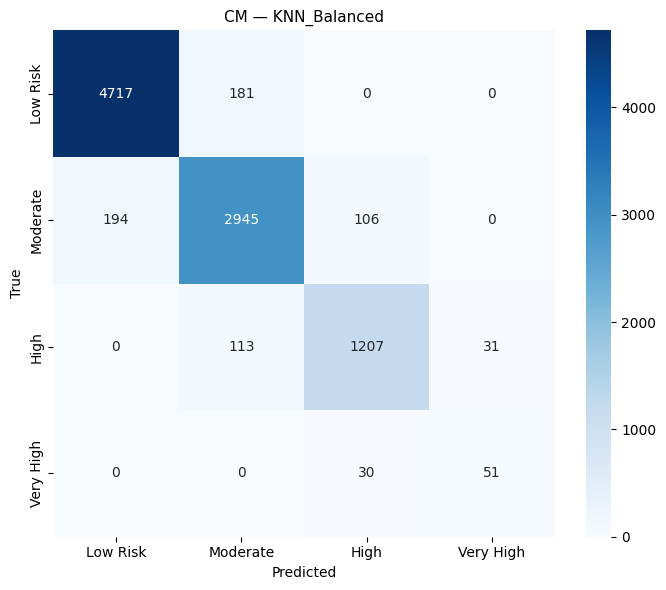


──────────────────────────────────────────────────
Training KNN (Imbalanced)...

  KNN (Imbalanced) — Test
  Acc=0.9459  F1=0.7882  Kappa=0.9095  ROC=0.9891
              precision    recall  f1-score   support

    Low Risk       0.97      0.98      0.97      4898
    Moderate       0.92      0.94      0.93      3245
        High       0.93      0.87      0.90      1351
   Very High       1.00      0.21      0.35        81

    accuracy                           0.95      9575
   macro avg       0.95      0.75      0.79      9575
weighted avg       0.95      0.95      0.94      9575



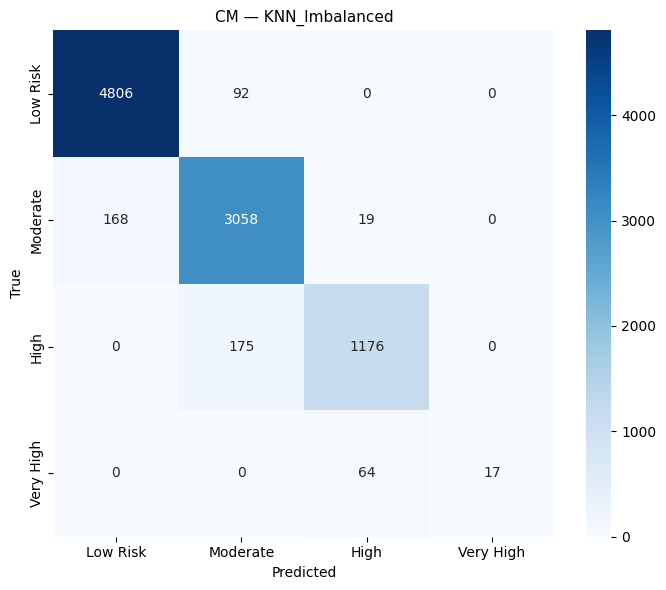


──────────────────────────────────────────────────
Training SVC (Balanced)...

  SVC (Balanced) — Test
  Acc=0.9807  F1=0.9280  Kappa=0.9681  ROC=0.9992
              precision    recall  f1-score   support

    Low Risk       1.00      0.99      0.99      4898
    Moderate       0.97      0.98      0.98      3245
        High       0.96      0.96      0.96      1351
   Very High       0.70      0.90      0.78        81

    accuracy                           0.98      9575
   macro avg       0.91      0.96      0.93      9575
weighted avg       0.98      0.98      0.98      9575



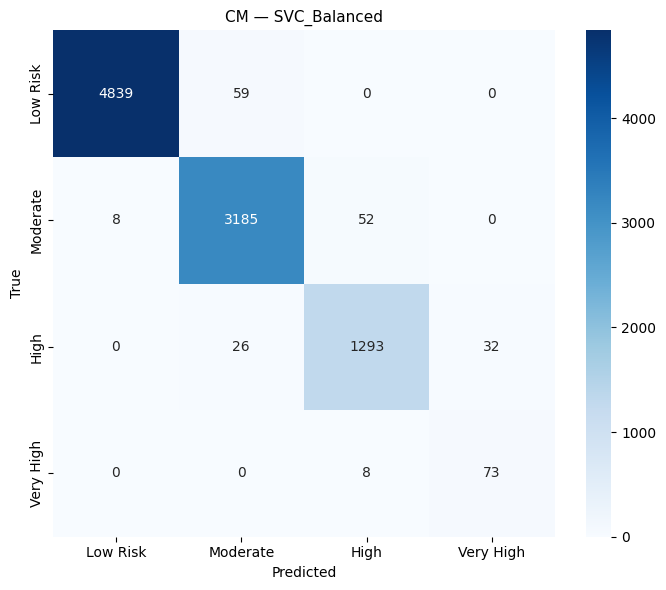


──────────────────────────────────────────────────
Training SVC (Imbalanced)...

  SVC (Imbalanced) — Test
  Acc=0.9750  F1=0.9000  Kappa=0.9589  ROC=0.9997
              precision    recall  f1-score   support

    Low Risk       1.00      0.99      0.99      4898
    Moderate       0.98      0.97      0.97      3245
        High       0.92      0.96      0.94      1351
   Very High       0.58      0.88      0.70        81

    accuracy                           0.98      9575
   macro avg       0.87      0.95      0.90      9575
weighted avg       0.98      0.98      0.98      9575



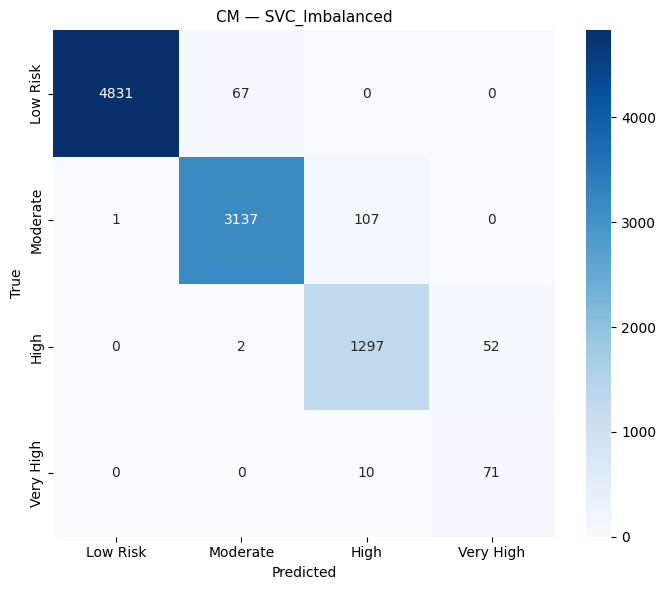


──────────────────────────────────────────────────
Training NaiveBayes (Balanced)...

  NaiveBayes (Balanced) — Test
  Acc=0.7364  F1=0.6367  Kappa=0.5831  ROC=0.915
              precision    recall  f1-score   support

    Low Risk       0.92      0.72      0.81      4898
    Moderate       0.63      0.78      0.69      3245
        High       0.69      0.69      0.69      1351
   Very High       0.22      0.99      0.36        81

    accuracy                           0.74      9575
   macro avg       0.61      0.79      0.64      9575
weighted avg       0.78      0.74      0.75      9575



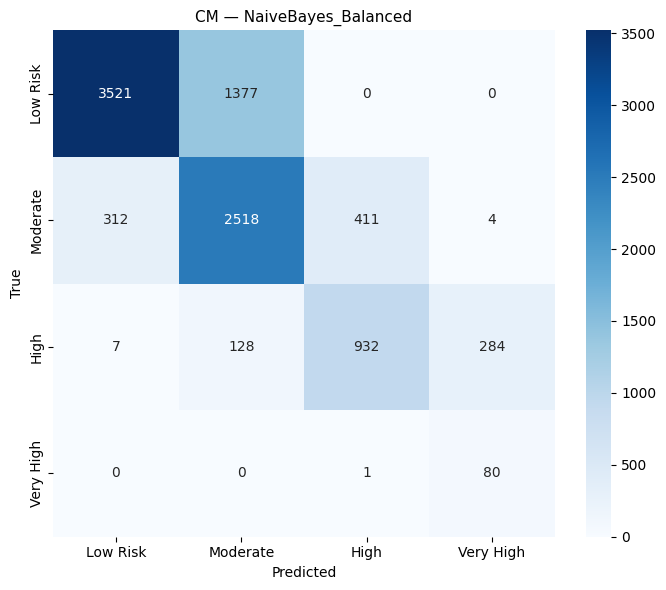


──────────────────────────────────────────────────
Training NaiveBayes (Imbalanced)...

  NaiveBayes (Imbalanced) — Test
  Acc=0.7731  F1=0.7367  Kappa=0.6338  ROC=0.925
              precision    recall  f1-score   support

    Low Risk       0.91      0.74      0.82      4898
    Moderate       0.64      0.83      0.72      3245
        High       0.80      0.77      0.79      1351
   Very High       0.59      0.67      0.62        81

    accuracy                           0.77      9575
   macro avg       0.73      0.75      0.74      9575
weighted avg       0.80      0.77      0.78      9575



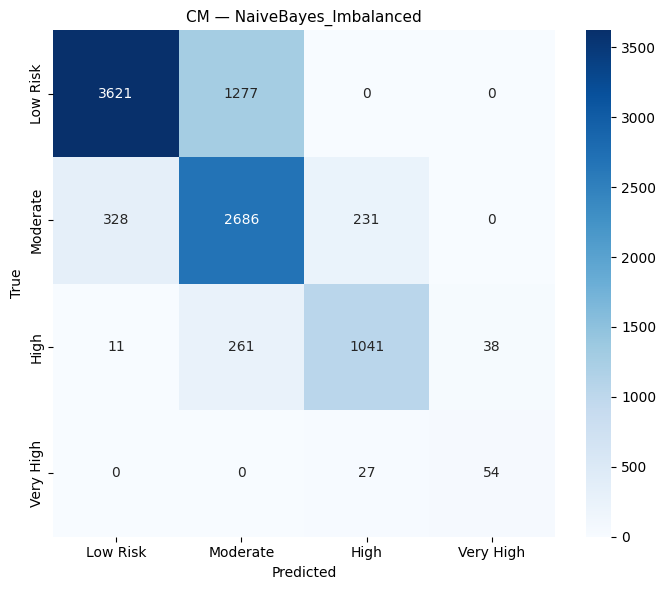


──────────────────────────────────────────────────
Training RandomForest (Balanced)...

  RandomForest (Balanced) — Test
  Acc=0.9939  F1=0.9609  Kappa=0.9900  ROC=0.9999
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      4898
    Moderate       1.00      0.99      0.99      3245
        High       0.99      0.98      0.99      1351
   Very High       0.79      0.95      0.87        81

    accuracy                           0.99      9575
   macro avg       0.94      0.98      0.96      9575
weighted avg       0.99      0.99      0.99      9575



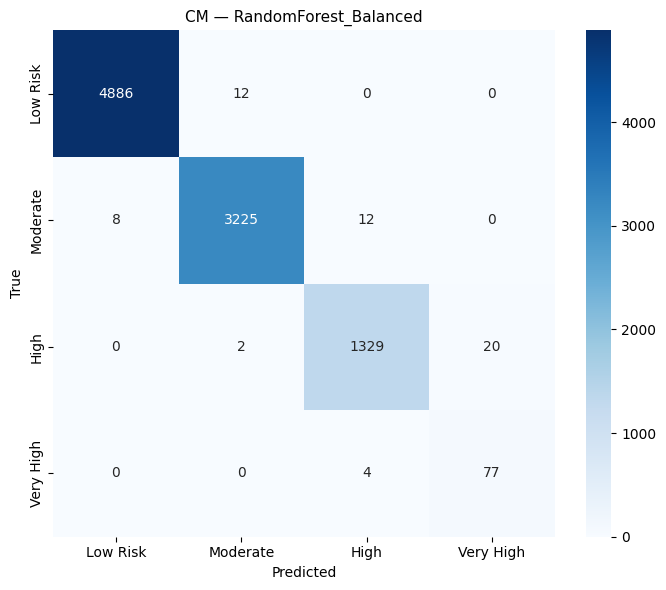


──────────────────────────────────────────────────
Training RandomForest (Imbalanced)...

  RandomForest (Imbalanced) — Test
  Acc=0.9943  F1=0.9564  Kappa=0.9905  ROC=1.0
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      4898
    Moderate       0.99      1.00      0.99      3245
        High       0.98      0.99      0.98      1351
   Very High       0.97      0.75      0.85        81

    accuracy                           0.99      9575
   macro avg       0.99      0.93      0.96      9575
weighted avg       0.99      0.99      0.99      9575



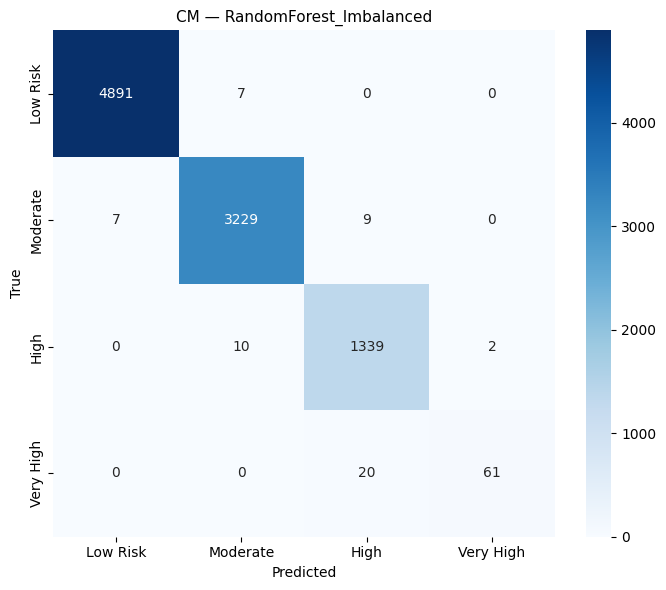


──────────────────────────────────────────────────
Training AdaBoost (Balanced)...

  AdaBoost (Balanced) — Test
  Acc=0.8728  F1=0.8048  Kappa=0.7964  ROC=0.9419
              precision    recall  f1-score   support

    Low Risk       1.00      0.89      0.94      4898
    Moderate       0.83      0.82      0.82      3245
        High       0.68      0.95      0.79      1351
   Very High       0.58      0.78      0.66        81

    accuracy                           0.87      9575
   macro avg       0.77      0.86      0.80      9575
weighted avg       0.89      0.87      0.88      9575



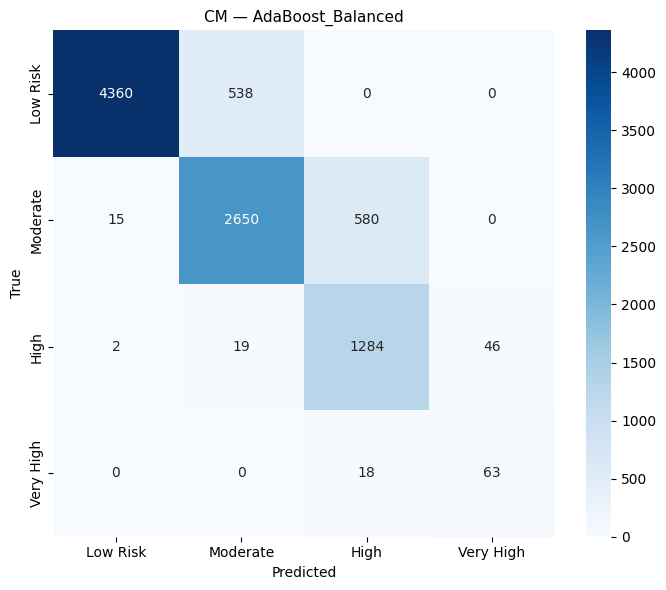


──────────────────────────────────────────────────
Training AdaBoost (Imbalanced)...

  AdaBoost (Imbalanced) — Test
  Acc=0.9315  F1=0.6936  Kappa=0.8868  ROC=0.9745
              precision    recall  f1-score   support

    Low Risk       0.98      0.94      0.96      4898
    Moderate       0.88      0.95      0.91      3245
        High       0.89      0.91      0.90      1351
   Very High       0.00      0.00      0.00        81

    accuracy                           0.93      9575
   macro avg       0.69      0.70      0.69      9575
weighted avg       0.93      0.93      0.93      9575



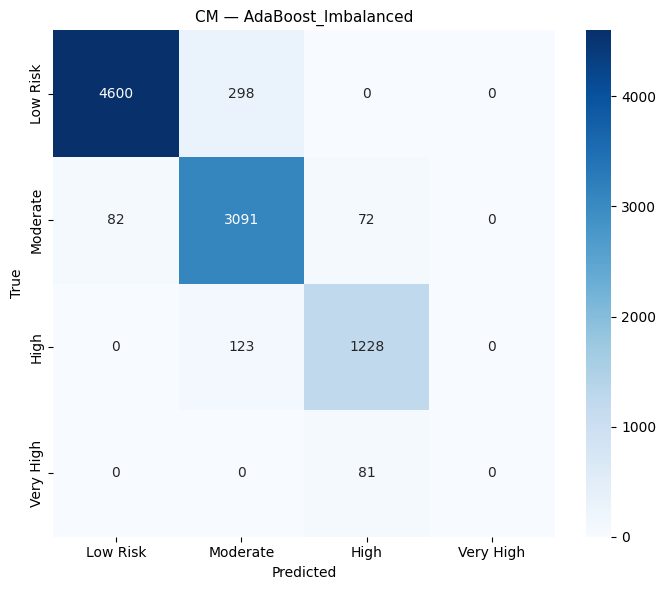


──────────────────────────────────────────────────
Training LDA (Balanced)...

  LDA (Balanced) — Test
  Acc=0.8334  F1=0.7716  Kappa=0.7365  ROC=0.9679
              precision    recall  f1-score   support

    Low Risk       1.00      0.76      0.86      4898
    Moderate       0.72      0.91      0.80      3245
        High       0.80      0.91      0.85      1351
   Very High       0.40      0.99      0.57        81

    accuracy                           0.83      9575
   macro avg       0.73      0.89      0.77      9575
weighted avg       0.87      0.83      0.84      9575



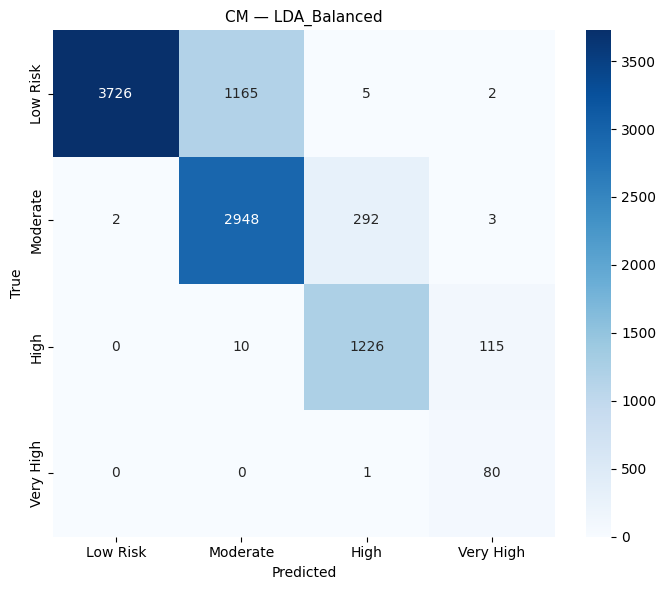


──────────────────────────────────────────────────
Training LDA (Imbalanced)...

  LDA (Imbalanced) — Test
  Acc=0.8998  F1=0.6585  Kappa=0.8325  ROC=0.9817
              precision    recall  f1-score   support

    Low Risk       0.99      0.95      0.97      4898
    Moderate       0.81      0.95      0.88      3245
        High       0.83      0.65      0.73      1351
   Very High       0.19      0.04      0.06        81

    accuracy                           0.90      9575
   macro avg       0.70      0.65      0.66      9575
weighted avg       0.90      0.90      0.90      9575



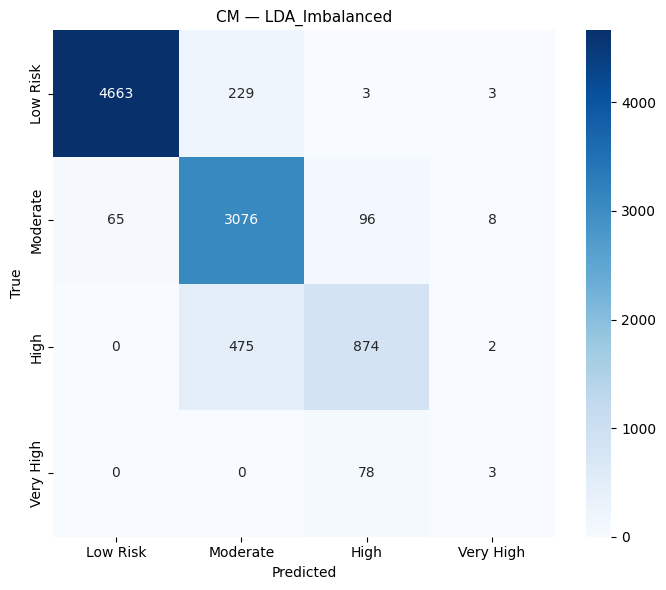


──────────────────────────────────────────────────
Training EasyEnsemble (Imbalanced)...

  EasyEnsemble (Imbalanced) — Test
  Acc=0.6199  F1=0.5954  Kappa=0.4333  ROC=0.836
              precision    recall  f1-score   support

    Low Risk       1.00      0.36      0.53      4898
    Moderate       0.48      0.90      0.63      3245
        High       0.83      0.87      0.85      1351
   Very High       0.23      0.99      0.37        81

    accuracy                           0.62      9575
   macro avg       0.64      0.78      0.60      9575
weighted avg       0.79      0.62      0.61      9575



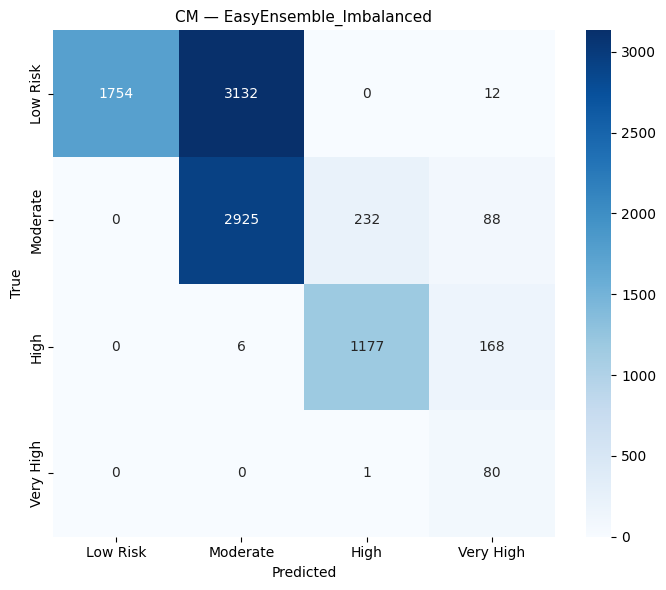


──────────────────────────────────────────────────
Training RUSBoost (Imbalanced)...

  RUSBoost (Imbalanced) — Test
  Acc=0.6543  F1=0.5039  Kappa=0.4739  ROC=0.891
              precision    recall  f1-score   support

    Low Risk       0.94      0.57      0.71      4898
    Moderate       0.51      0.67      0.58      3245
        High       0.59      0.96      0.73      1351
   Very High       0.00      0.00      0.00        81

    accuracy                           0.65      9575
   macro avg       0.51      0.55      0.50      9575
weighted avg       0.74      0.65      0.66      9575



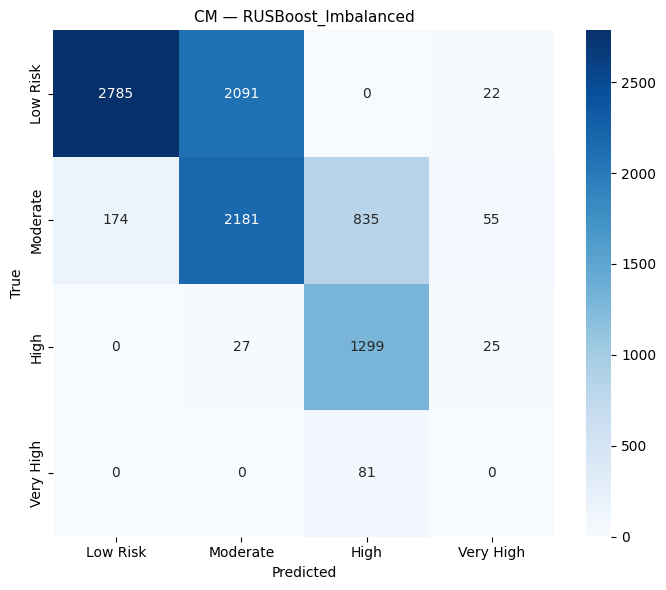


──────────────────────────────────────────────────
Training BBAG (Imbalanced)...

  BBAG (Imbalanced) — Test
  Acc=0.9431  F1=0.8190  Kappa=0.9071  ROC=0.995
              precision    recall  f1-score   support

    Low Risk       1.00      0.96      0.98      4898
    Moderate       0.94      0.94      0.94      3245
        High       0.88      0.88      0.88      1351
   Very High       0.31      1.00      0.48        81

    accuracy                           0.94      9575
   macro avg       0.78      0.94      0.82      9575
weighted avg       0.96      0.94      0.95      9575



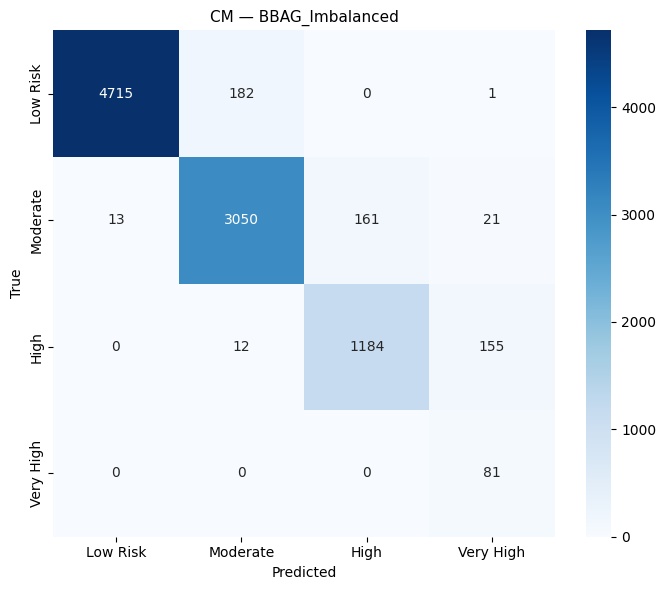

BalancedBaggingClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
# CELL 9 — Sklearn Baselines
train_sklearn(KNeighborsClassifier(n_neighbors=5,n_jobs=-1),'KNN',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(KNeighborsClassifier(n_neighbors=5,n_jobs=-1),'KNN',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(SVC(kernel='rbf',probability=True,random_state=SEED),'SVC',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(SVC(kernel='rbf',probability=True,class_weight='balanced',random_state=SEED),'SVC',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(GaussianNB(),'NaiveBayes',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(GaussianNB(),'NaiveBayes',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(AdaBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'AdaBoost',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(AdaBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'AdaBoost',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(LinearDiscriminantAnalysis(),'LDA',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(LinearDiscriminantAnalysis(),'LDA',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(EasyEnsembleClassifier(n_estimators=10,random_state=SEED,n_jobs=-1),'EasyEnsemble',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(RUSBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'RUSBoost',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(BalancedBaggingClassifier(n_estimators=50,random_state=SEED,n_jobs=-1),'BBAG',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')

In [ ]:
ALL_RESULTS[:] = [r for r in ALL_RESULTS if r['Model'] != 'RandomForest']
print(f'✅ RandomForest removed. Remaining: {len(ALL_RESULTS)} entries')
print('Models left:', sorted(set(r['Model'] for r in ALL_RESULTS)))

✅ RandomForest removed. Remaining: 57 entries
Models left: ['AdaBoost', 'BBAG', 'EasyEnsemble', 'KNN', 'LDA', 'NaiveBayes', 'RUSBoost', 'SAINT', 'SAINT-XGB-Stack', 'SVC', 'XGBoost']



═══ Training SAINT baseline (Balanced) ═══

──────────────────────────────────────────────────
Training SAINT (Balanced)...


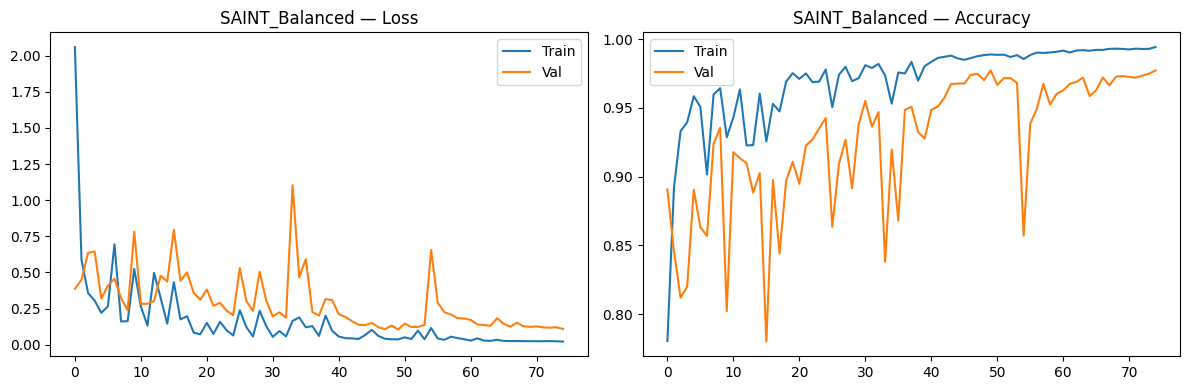


  SAINT (Balanced) — Test
  Acc=0.9784  F1=0.8949  Kappa=0.9643  ROC=0.9972
              precision    recall  f1-score   support

    Low Risk       0.99      0.99      0.99      4898
    Moderate       0.98      0.98      0.98      3245
        High       0.97      0.93      0.95      1351
   Very High       0.49      1.00      0.65        81

    accuracy                           0.98      9575
   macro avg       0.86      0.98      0.89      9575
weighted avg       0.98      0.98      0.98      9575



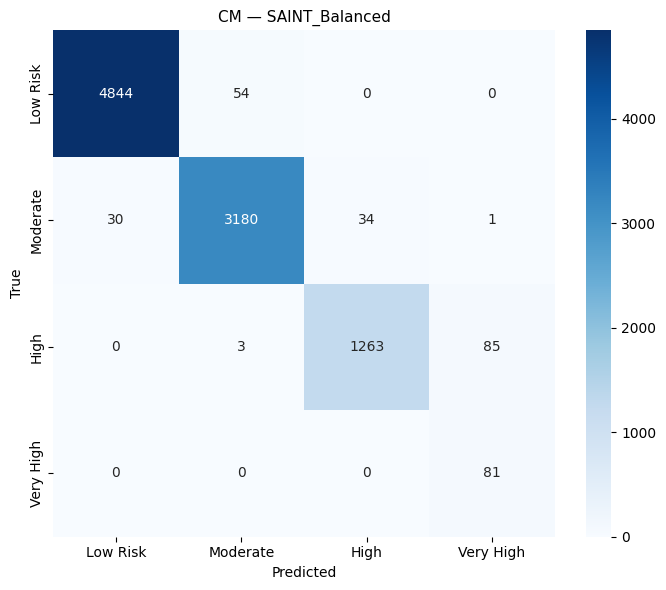


═══ Training SAINT baseline (Imbalanced) ═══

──────────────────────────────────────────────────
Training SAINT (Imbalanced)...


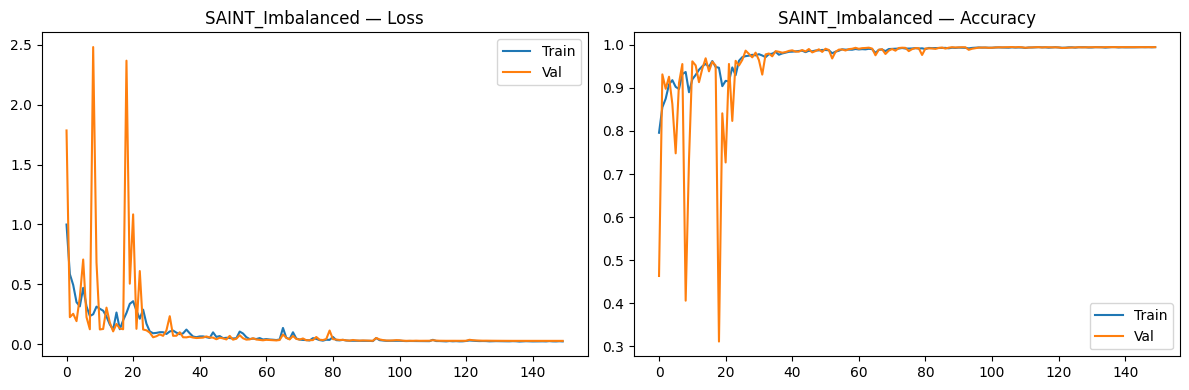


  SAINT (Imbalanced) — Test
  Acc=0.9940  F1=0.9596  Kappa=0.9901  ROC=0.9999
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      4898
    Moderate       1.00      0.99      1.00      3245
        High       0.99      0.98      0.99      1351
   Very High       0.80      0.93      0.86        81

    accuracy                           0.99      9575
   macro avg       0.95      0.98      0.96      9575
weighted avg       0.99      0.99      0.99      9575



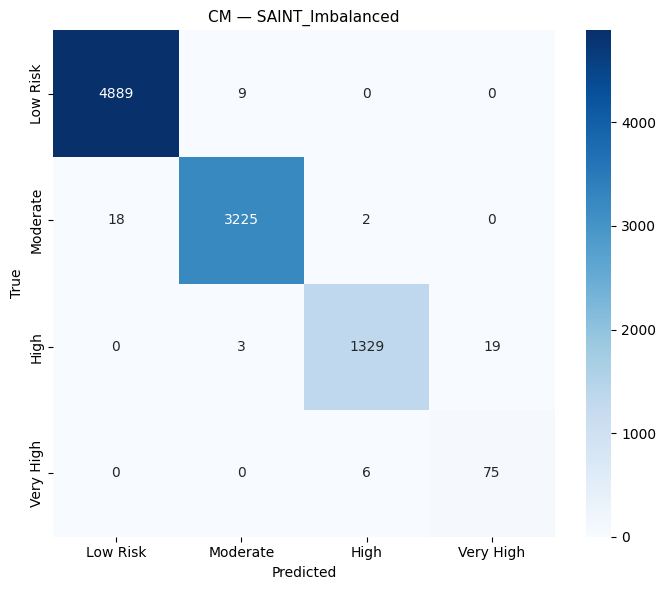


═══ Training XGBoost baseline (Balanced) ═══

──────────────────────────────────────────────────
Training XGBoost (Balanced)...

  XGBoost (Balanced) — Test
  Acc=0.9934  F1=0.9525  Kappa=0.9891  ROC=0.9999
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      4898
    Moderate       1.00      0.99      1.00      3245
        High       0.99      0.98      0.98      1351
   Very High       0.72      0.99      0.83        81

    accuracy                           0.99      9575
   macro avg       0.93      0.99      0.95      9575
weighted avg       0.99      0.99      0.99      9575



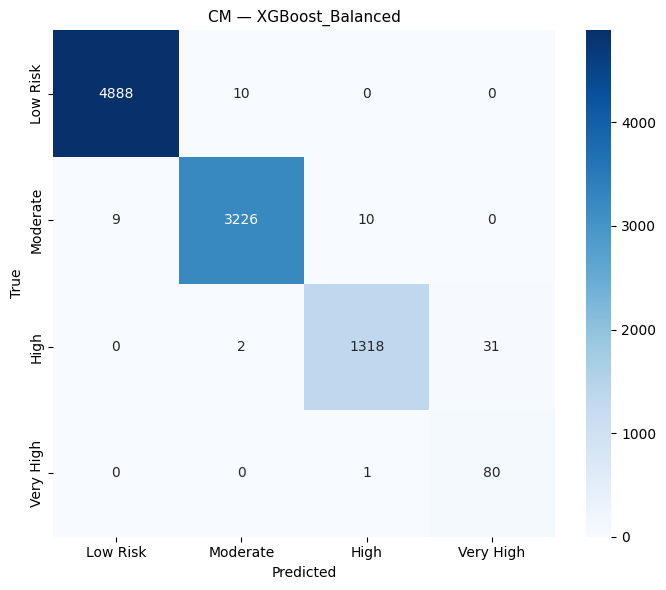


██████████████████████████████████████████████████████████████████████
  ★ PROPOSED MODEL: Stacked Ensemble (SAINT × XGBoost × RF → LR)
██████████████████████████████████████████████████████████████████████

Building Stacked Ensemble with 5-fold CV meta-features...
  Base learners: SAINT + XGBoost + RandomForest
  Meta-learner:  Logistic Regression (multinomial)
    ⏳ SAINTClassifier.fit() | samples=95705 | 13:04:52
    ✅ SAINTClassifier done | 13:22:54
    ⏳ SAINTClassifier.fit() | samples=76564 | 13:23:36
    ✅ SAINTClassifier done | 13:38:41
    ⏳ SAINTClassifier.fit() | samples=76564 | 13:38:48
    ✅ SAINTClassifier done | 13:53:33
    ⏳ SAINTClassifier.fit() | samples=76564 | 13:53:40


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — SAINT Baseline + Stacked Ensemble (PROPOSED MODEL)             ║
# ║                                                                            ║
# ║  1) SAINT standalone baseline (Balanced & Imbalanced)                      ║
# ║  2) XGBoost standalone baseline (Balanced)                                 ║
# ║  3) ★ PROPOSED: Stacked Ensemble  [SAINT + XGBoost + RF → LR]            ║
# ║                                                                            ║
# ║  Stacking rationale:                                                       ║
# ║  • SAINT captures complex non-linear feature interactions via dual         ║
# ║    attention (column + intersample) — strong on subtle class boundaries    ║
# ║  • XGBoost excels at axis-aligned decision boundaries                      ║
# ║  • RandomForest provides stable bagged-tree diversity                      ║
# ║  • Logistic Regression meta-learner learns optimal weighting               ║
# ║  • Uses 5-fold CV for generating meta-features (no data leakage)          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─── 1) SAINT Baseline ────────────────────────────────────────────────────────
print('\n═══ Training SAINT baseline (Balanced) ═══')
saint_bal, _ = train_dl(
    build_saint(n_features, n_classes, d_token=64, n_heads=8, n_layers=3, seed=SEED),
    'SAINT', X_tr_bal, y_tr_bal_idx,
    X_v_bal, y_val,
    X_te_bal, y_test,
    'Balanced', use_cw=True, patience=25
)

print('\n═══ Training SAINT baseline (Imbalanced) ═══')
saint_imb, _ = train_dl(
    build_saint(n_features, n_classes, d_token=64, n_heads=8, n_layers=3, seed=SEED),
    'SAINT', X_tr_imb, y_tr_imb_idx,
    X_v_imb, y_val,
    X_te_imb, y_test,
    'Imbalanced', use_cw=True, patience=25
)

# ─── 2) XGBoost Baseline ──────────────────────────────────────────────────────
print('\n═══ Training XGBoost baseline (Balanced) ═══')
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=SEED, n_jobs=-1, verbosity=0
)
train_sklearn(xgb_model, 'XGBoost', X_tr_bal, y_train_bal,
              X_v_bal, y_val, X_te_bal, y_test, 'Balanced')

# ─── 3) ★ PROPOSED: Stacked Ensemble (SAINT + XGBoost + RF → LR) ─────────────
print('\n' + '█'*70)
print('  ★ PROPOSED MODEL: Stacked Ensemble (SAINT × XGBoost × RF → LR)')
print('█'*70)

from sklearn.base import BaseEstimator, ClassifierMixin

class SAINTClassifier(BaseEstimator, ClassifierMixin):
    """
    Sklearn-compatible wrapper around the Keras SAINT model.
    Uses 10% internal holdout for val_loss early stopping.
    """
    def __init__(self, n_features=10, n_classes=4, d_token=64, n_heads=8,
                 n_layers=3, epochs=150, batch_size=256, lr=1e-3,
                 patience=25, seed=42):
        self.n_features = n_features
        self.n_classes = n_classes
        self.d_token = d_token
        self.n_heads = n_heads
        self.n_layers = n_layers
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience
        self.seed = seed
        self.model_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.sort(np.unique(y))
        y_idx = np.searchsorted(self.classes_, y)

        print(f'    ⏳ SAINTClassifier.fit() | samples={len(X)} | {time.strftime("%H:%M:%S")}')

        # 10% internal holdout for val_loss early stopping
        n_val = max(int(len(X) * 0.1), 100)
        indices = np.random.RandomState(self.seed).permutation(len(X))
        val_idx, tr_idx = indices[:n_val], indices[n_val:]

        self.model_ = build_saint(
            self.n_features, self.n_classes,
            d_token=self.d_token, n_heads=self.n_heads,
            n_layers=self.n_layers, seed=self.seed
        )
        self.model_.fit(
            X[tr_idx], y_idx[tr_idx],
            validation_data=(X[val_idx], y_idx[val_idx]),
            epochs=self.epochs,
            batch_size=self.batch_size,
            class_weight=CW_DICT,
            callbacks=[
                callbacks.EarlyStopping(monitor='val_loss', patience=self.patience,
                                        restore_best_weights=True, verbose=0),
                callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                            patience=8, min_lr=1e-7, verbose=0),
            ],
            verbose=0
        )
        print(f'    ✅ SAINTClassifier done | {time.strftime("%H:%M:%S")}')
        return self

    def predict(self, X):
        proba = self.model_.predict(X, verbose=0)
        return self.classes_[proba.argmax(1)]

    def predict_proba(self, X):
        return self.model_.predict(X, verbose=0)

# --- Build the 3-Model Stacking Ensemble ---
print('\nBuilding Stacked Ensemble with 5-fold CV meta-features...')
print('  Base learners: SAINT + XGBoost + RandomForest')
print('  Meta-learner:  Logistic Regression (multinomial)')
t0 = time.time()

stacking_model = StackingClassifier(
    estimators=[
        ('saint', SAINTClassifier(
            n_features=n_features, n_classes=n_classes,
            d_token=64, n_heads=8, n_layers=3,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            patience=25, seed=SEED
        )),
        ('xgboost', xgb.XGBClassifier(
            n_estimators=300, max_depth=8, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            use_label_encoder=False, eval_metric='mlogloss',
            random_state=SEED, n_jobs=-1, verbosity=0
        )),
        ('rf', RandomForestClassifier(
            n_estimators=300, max_depth=20,
            random_state=SEED, n_jobs=-1
        )),
    ],
    final_estimator=LogisticRegression(
        max_iter=1000, random_state=SEED, multi_class='multinomial',
        class_weight='balanced', C=1.0
    ),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=1,
    verbose=1
)

stacking_model.fit(X_tr_bal, y_train_bal)
tt_stack = time.time() - t0

# --- Evaluate ---
y_tr_pred_stk  = stacking_model.predict(X_tr_bal)
y_v_pred_stk   = stacking_model.predict(X_v_bal)
y_te_pred_stk  = stacking_model.predict(X_te_bal)
y_v_proba_stk  = stacking_model.predict_proba(X_v_bal)
y_te_proba_stk = stacking_model.predict_proba(X_te_bal)

full_evaluate(
    'SAINT-XGB-Stack',
    y_train_bal, y_tr_pred_stk,
    y_val, y_v_pred_stk, y_v_proba_stk,
    y_test, y_te_pred_stk, y_te_proba_stk,
    tt_stack, 'Balanced', print_tptn=True
)
plot_confusion(y_test, y_te_pred_stk, 'SAINT-XGB-Stack_Balanced')

print(f'\n★ Proposed model training complete! ({tt_stack/60:.1f} min)')

In [ ]:
ALL_RESULTS[:] = [r for r in ALL_RESULTS if r['Model'] != 'RandomForest']
print(f'✅ RandomForest removed. Remaining: {len(ALL_RESULTS)} entries')
print('Models left:', sorted(set(r['Model'] for r in ALL_RESULTS)))

✅ RandomForest removed. Remaining: 57 entries
Models left: ['AdaBoost', 'BBAG', 'EasyEnsemble', 'KNN', 'LDA', 'NaiveBayes', 'RUSBoost', 'SAINT', 'SAINT-XGB-Stack', 'SVC', 'XGBoost']


In [ ]:
# CELL 12 — Results Tables + Final Ranking
results_df     = pd.DataFrame(ALL_RESULTS)
results_df.to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_ALL_results_nambiar.csv'),index=False)

test_df        = results_df[results_df['Split']=='Test'].copy()
best_per_model = (test_df.sort_values('F1_macro',ascending=False)
                         .groupby('Model').first().reset_index()
                         .sort_values('F1_macro',ascending=False))

cols = ['Model','Training_Type','Accuracy','F1_macro','Precision','Recall','Kappa','ROC_AUC','Train_Time_s']
print('\n' + '='*80)
print(f'  TABLE 1 — TEST RESULTS | {STATION} ({STATION_ID}) | {TARGET}')
print('='*80)
print(best_per_model[cols].to_string(index=False))
best_per_model[cols].to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table1_best_test.csv'),index=False)

# Component evaluation: SAINT alone vs XGBoost alone vs Stacked (proposed)
print('\n' + '='*80)
print('  TABLE 3 — COMPONENT EVALUATION (Proposed Stacked Ensemble)')
print('='*80)
comp_rows=[]
for m in ['SAINT','XGBoost','BBAG','SAINT-XGB-Stack']:
    r=results_df[(results_df['Model']==m)&(results_df['Split']=='Test')]
    if len(r):
        row=r.iloc[0]
        comp_rows.append({'Model':m,'Accuracy':row['Accuracy'],'F1_macro':row['F1_macro'],
                          'Recall':row['Recall'],'Precision':row['Precision'],
                          'Kappa':row['Kappa'],'ROC_AUC':row.get('ROC_AUC',np.nan)})
comp3=pd.DataFrame(comp_rows)
print(comp3.to_string(index=False))
comp3.to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table3_component.csv'),index=False)
print('\n✅ Tables saved.')


  TABLE 1 — TEST RESULTS | Colaba (43057) | HI
          Model Training_Type  Accuracy  F1_macro  Precision  Recall  Kappa  ROC_AUC  Train_Time_s
SAINT-XGB-Stack      Balanced    0.9935    0.9561     0.9316  0.9894 0.9893   0.9999        4088.6
        XGBoost      Balanced    0.9934    0.9525     0.9267  0.9888 0.9891   0.9999           7.9
          SAINT      Balanced    0.9708    0.9439     0.9226  0.9734 0.9514   0.9986        1083.1
            SVC      Balanced    0.9807    0.9280     0.9058  0.9569 0.9681   0.9992         105.5
            KNN      Balanced    0.9316    0.8480     0.8476  0.8484 0.8866   0.9663           0.3
           BBAG    Imbalanced    0.9431    0.8190     0.7829  0.9447 0.9071   0.9950           0.9
       AdaBoost      Balanced    0.8728    0.8048     0.7707  0.8587 0.7964   0.9419           9.0
            LDA      Balanced    0.8334    0.7716     0.7297  0.8911 0.7365   0.9679           0.1
     NaiveBayes    Imbalanced    0.7731    0.7367     0.7347 

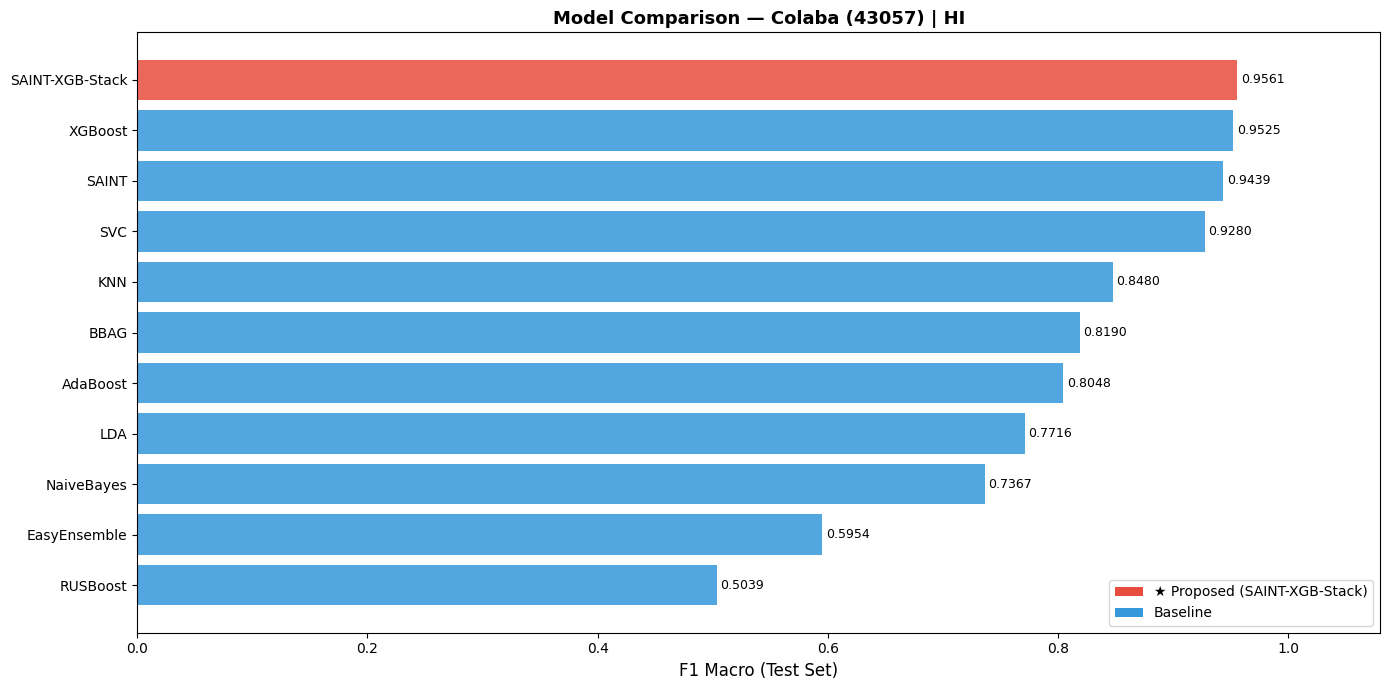

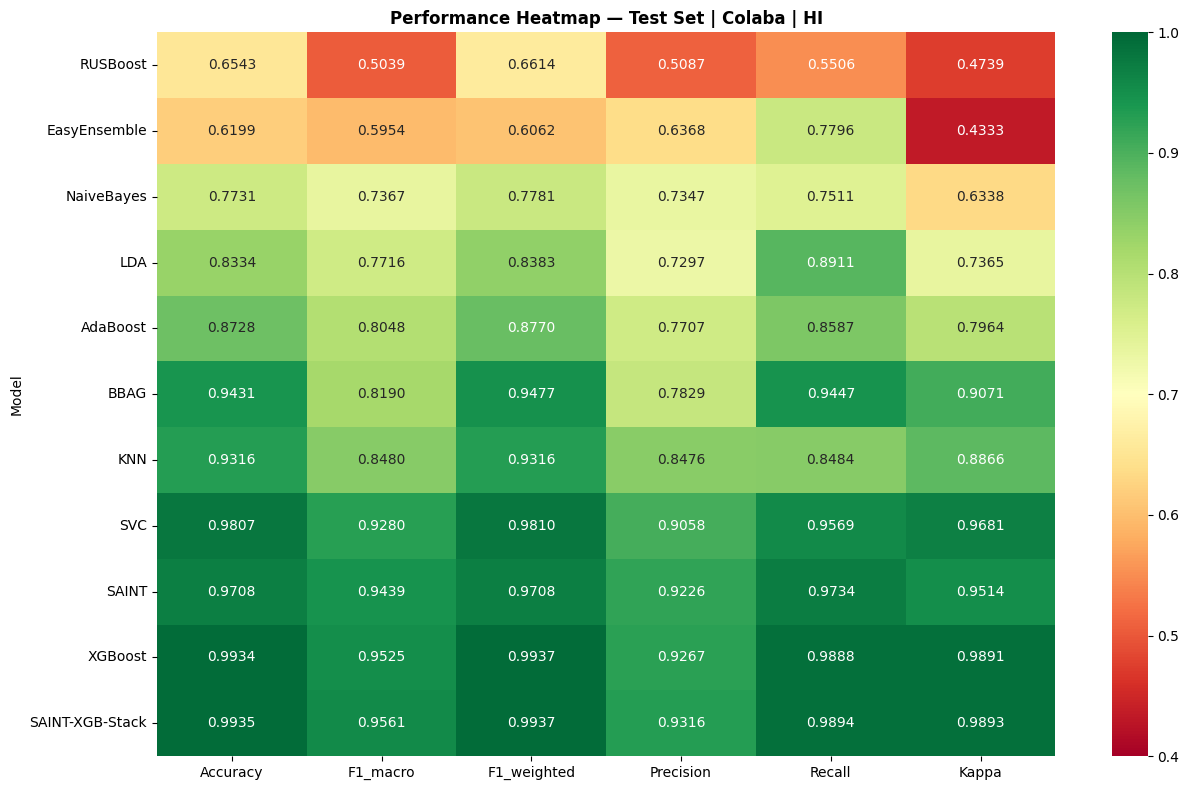

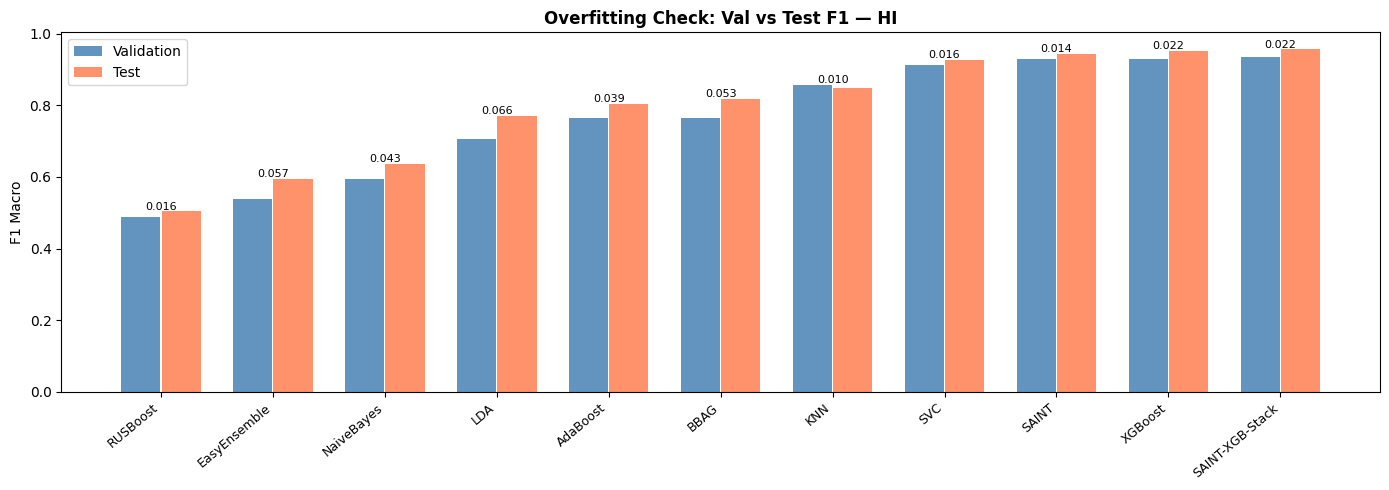

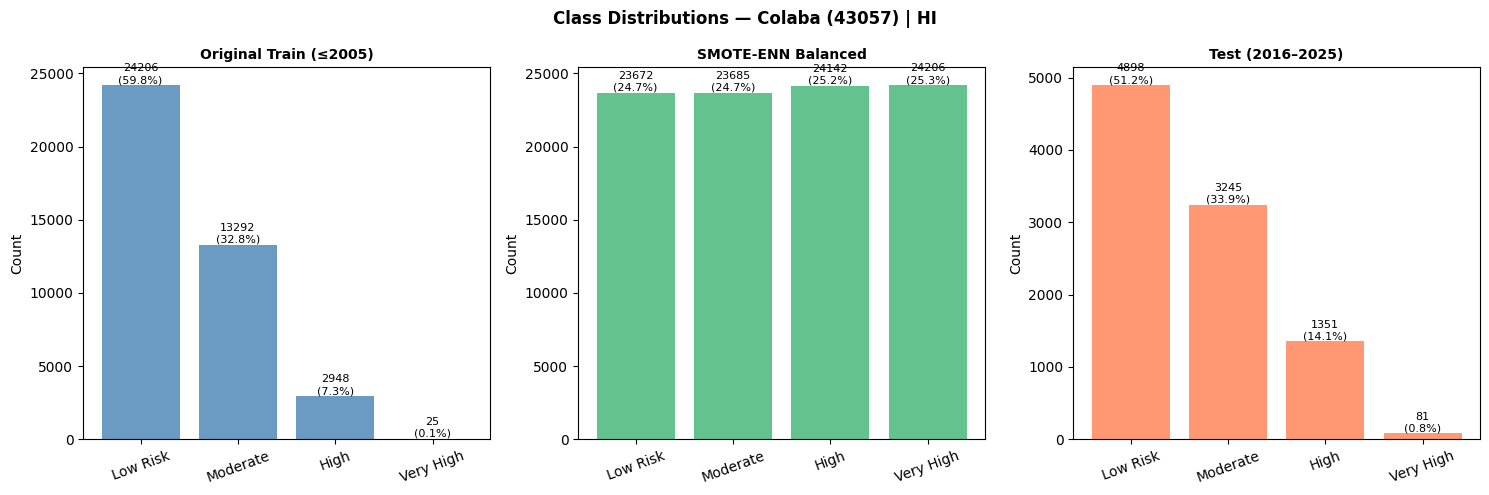

In [ ]:
# CELL 13 — Visualization Plots
results_df     = pd.DataFrame(ALL_RESULTS)
test_df        = results_df[results_df['Split']=='Test'].copy()
best_per_model = (test_df.sort_values('F1_macro',ascending=False)
                         .groupby('Model').first().reset_index()
                         .sort_values('F1_macro',ascending=True))

# PLOT 1: Model ranking
fig,ax=plt.subplots(figsize=(14,7))
colors=['#e74c3c' if 'Stack' in m else '#3498db' for m in best_per_model['Model']]
bars=ax.barh(best_per_model['Model'],best_per_model['F1_macro'],color=colors,alpha=0.85)
for bar,val in zip(bars,best_per_model['F1_macro']):
    ax.text(val+0.003,bar.get_y()+bar.get_height()/2,f'{val:.4f}',va='center',fontsize=9)
ax.set_xlabel('F1 Macro (Test Set)',fontsize=12); ax.set_xlim(0,1.08)
ax.set_title(f'Model Comparison — {STATION} ({STATION_ID}) | {TARGET}',fontsize=13,fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e74c3c',label='★ Proposed (SAINT-XGB-Stack)'),
    Patch(facecolor='#3498db',label='Baseline')
],fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot1_ranking.png'),dpi=150,bbox_inches='tight')
plt.show()

# PLOT 2: Heatmap
fig,ax=plt.subplots(figsize=(13,8))
heat=best_per_model.set_index('Model')[['Accuracy','F1_macro','F1_weighted','Precision','Recall','Kappa']]
sns.heatmap(heat.astype(float),annot=True,fmt='.4f',cmap='RdYlGn',vmin=0.4,vmax=1.0,ax=ax)
ax.set_title(f'Performance Heatmap — Test Set | {STATION} | {TARGET}',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot2_heatmap.png'),dpi=150,bbox_inches='tight')
plt.show()

# PLOT 3: Overfitting check
fig,ax=plt.subplots(figsize=(14,5))
mlist=best_per_model['Model'].tolist()
val_f1s,te_f1s=[],[]
for m in mlist:
    vr=results_df[(results_df['Model']==m)&(results_df['Split']=='Validation')]
    tr=results_df[(results_df['Model']==m)&(results_df['Split']=='Test')]
    val_f1s.append(vr['F1_macro'].values[0] if len(vr) else 0)
    te_f1s.append(tr['F1_macro'].values[0] if len(tr) else 0)
x=np.arange(len(mlist))
ax.bar(x-0.18,val_f1s,0.35,label='Validation',color='steelblue',alpha=0.85)
ax.bar(x+0.18,te_f1s, 0.35,label='Test',      color='coral',    alpha=0.85)
for i in range(len(mlist)):
    ax.text(i,max(val_f1s[i],te_f1s[i])+0.004,f'{abs(val_f1s[i]-te_f1s[i]):.3f}',ha='center',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(mlist,rotation=40,ha='right',fontsize=9)
ax.set_ylabel('F1 Macro'); ax.set_title(f'Overfitting Check: Val vs Test F1 — {TARGET}',fontsize=12,fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot3_overfit.png'),dpi=150,bbox_inches='tight')
plt.show()

# PLOT 4: Class distribution
fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,(data_arr,title,color) in zip(axes,[
    (y_train_raw,f'Original Train (≤{TRAIN_END})','steelblue'),
    (y_train_bal,'SMOTE-ENN Balanced','mediumseagreen'),
    (y_test,f'Test ({VAL_END+1}–2025)','coral')
]):
    counts=[np.sum(data_arr==c) for c in ALL_CLASSES]
    bars=ax.bar(CLASS_NAMES,counts,color=color,alpha=0.8)
    for bar,cnt in zip(bars,counts):
        pct=100*cnt/len(data_arr)
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f'{cnt}\n({pct:.1f}%)',ha='center',va='bottom',fontsize=8)
    ax.set_title(title,fontsize=10,fontweight='bold'); ax.set_ylabel('Count'); ax.tick_params(axis='x',rotation=20)
fig.suptitle(f'Class Distributions — {STATION} ({STATION_ID}) | {TARGET}',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot4_class_dist.png'),dpi=150,bbox_inches='tight')
plt.show()

In [ ]:
# CELL 14 — Final Summary
results_df     = pd.DataFrame(ALL_RESULTS)
test_df        = results_df[results_df['Split']=='Test'].copy()
best_per_model = (test_df.sort_values('F1_macro',ascending=False)
                         .groupby('Model').first().reset_index()
                         .sort_values('F1_macro',ascending=False))

print('\n' + '='*70)
print(f'  ✅ ALL DONE — {STATION} ({STATION_ID}) | {TARGET}')
print(f'  Models : {len(set(results_df["Model"]))} | Results: {OUTPUT_DIR}')
print('='*70)
print('\nFinal ranking (Test F1 macro):')
for i,(_, row) in enumerate(best_per_model.iterrows(),1):
    tag = '★' if row['Model'] == 'SAINT-XGB-Stack' else ' '
    print(f'  {tag} {i:2d}. {row["Model"]:<22s}  F1={row["F1_macro"]:.4f}  Acc={row["Accuracy"]:.4f}  ({row["Training_Type"]})')

print()
print('  Test Performance (★ Proposed: SAINT-XGB-Stack):')
test_proposed = test_df[test_df['Model']=='SAINT-XGB-Stack'].iloc[0]
print(f'    Accuracy  : {test_proposed["Accuracy"]:.4f}')
print(f'    F1 macro  : {test_proposed["F1_macro"]:.4f}  ← proposed stacked ensemble')
print(f'    Kappa     : {test_proposed["Kappa"]:.4f}')
print(f'    ROC-AUC   : {test_proposed["ROC_AUC"]:.4f}')
print('='*70)


  ✅ ALL DONE — Colaba (43057) | HI
  Models : 11 | Results: /content/drive/MyDrive/Major_project_imd/43057-HI-Model-final results

Final ranking (Test F1 macro):
  ★  1. SAINT-XGB-Stack         F1=0.9561  Acc=0.9935  (Balanced)
     2. XGBoost                 F1=0.9525  Acc=0.9934  (Balanced)
     3. SAINT                   F1=0.9439  Acc=0.9708  (Balanced)
     4. SVC                     F1=0.9280  Acc=0.9807  (Balanced)
     5. KNN                     F1=0.8480  Acc=0.9316  (Balanced)
     6. BBAG                    F1=0.8190  Acc=0.9431  (Imbalanced)
     7. AdaBoost                F1=0.8048  Acc=0.8728  (Balanced)
     8. LDA                     F1=0.7716  Acc=0.8334  (Balanced)
     9. NaiveBayes              F1=0.7367  Acc=0.7731  (Imbalanced)
    10. EasyEnsemble            F1=0.5954  Acc=0.6199  (Imbalanced)
    11. RUSBoost                F1=0.5039  Acc=0.6543  (Imbalanced)

  Test Performance (★ Proposed: SAINT-XGB-Stack):
    Accuracy  : 0.9935
    F1 macro  : 0.9561  ← pro

In [ ]:
# TABLE 1A — TEST SET RESULTS (already exists, kept for reference)
print("\n" + "═"*80)
print(f"  TABLE 1A — TEST SET RESULTS (Best per model) | {STATION} ({STATION_ID}) | {TARGET}")
print("═"*80)
cols = ['Model','Training_Type','Accuracy','F1_macro','Precision','Recall','Kappa','ROC_AUC','Train_Time_s']
print(best_per_model[cols].to_string(index=False))
best_per_model[cols].to_csv(
    os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_table1a_best_test.csv'), index=False)

# TABLE 1B — VALIDATION SET RESULTS (matching best training type from test)
print("\n" + "═"*80)
print(f"  TABLE 1B — VALIDATION SET RESULTS (same training type as best test) | {STATION} ({STATION_ID}) | {TARGET}")
print("═"*80)

val_rows = []
for _, row in best_per_model.iterrows():
    m, bt = row['Model'], row['Training_Type']
    vr = results_df[(results_df['Model']==m) &
                     (results_df['Split']=='Validation') &
                     (results_df['Training_Type']==bt)]
    if len(vr):
        val_rows.append(vr.iloc[0])

val_df = pd.DataFrame(val_rows).sort_values('F1_macro', ascending=False)
print(val_df[cols].to_string(index=False))
val_df[cols].to_csv(
    os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_table1b_best_val.csv'), index=False)

# TABLE 1C — TRAIN vs VAL vs TEST F1 COMPARISON
print('\n' + '='*80)
print(f'  TABLE 1C — TRAIN vs VAL vs TEST F1 COMPARISON | {TARGET}')
print('='*80)
comparison_rows = []
for _, row in best_per_model.iterrows():
    m, bt = row['Model'], row['Training_Type']
    tr_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Train')      & (results_df['Training_Type']==bt)]
    val_r = results_df[(results_df['Model']==m) & (results_df['Split']=='Validation')  & (results_df['Training_Type']==bt)]
    te_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Test')        & (results_df['Training_Type']==bt)]
    tr_f1  = tr_r['F1_macro'].values[0]  if len(tr_r)  else np.nan
    val_f1 = val_r['F1_macro'].values[0] if len(val_r) else np.nan
    te_f1  = te_r['F1_macro'].values[0]  if len(te_r)  else np.nan
    comparison_rows.append({
        'Model': m, 'Training_Type': bt,
        'Train_F1': round(tr_f1,4), 'Val_F1': round(val_f1,4), 'Test_F1': round(te_f1,4),
        'Δ1_Train→Val': round(tr_f1-val_f1,4), 'Δ2_Val→Test': round(val_f1-te_f1,4),
    })
comp_df = pd.DataFrame(comparison_rows).sort_values('Test_F1', ascending=False)
print(comp_df.to_string(index=False))
comp_df.to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table1c_overfit_analysis.csv'),index=False)



print(f"\n✅ Tables 1A, 1B. 1C saved to {OUTPUT_DIR}")


════════════════════════════════════════════════════════════════════════════════
  TABLE 1A — TEST SET RESULTS (Best per model) | Colaba (43057) | HI
════════════════════════════════════════════════════════════════════════════════
          Model Training_Type  Accuracy  F1_macro  Precision  Recall  Kappa  ROC_AUC  Train_Time_s
SAINT-XGB-Stack      Balanced    0.9935    0.9561     0.9316  0.9894 0.9893   0.9999        4088.6
        XGBoost      Balanced    0.9934    0.9525     0.9267  0.9888 0.9891   0.9999           7.9
          SAINT      Balanced    0.9708    0.9439     0.9226  0.9734 0.9514   0.9986        1083.1
            SVC      Balanced    0.9807    0.9280     0.9058  0.9569 0.9681   0.9992         105.5
            KNN      Balanced    0.9316    0.8480     0.8476  0.8484 0.8866   0.9663           0.3
           BBAG    Imbalanced    0.9431    0.8190     0.7829  0.9447 0.9071   0.9950           0.9
       AdaBoost      Balanced    0.8728    0.8048     0.7707  0.8587 0.7964

In [ ]:
# TABLE 1C — TRAIN vs VAL vs TEST F1 COMPARISON
print('\n' + '='*80)
print(f'  TABLE 1C — TRAIN vs VAL vs TEST F1 COMPARISON | {TARGET}')
print('='*80)
comparison_rows = []
for _, row in best_per_model.iterrows():
    m, bt = row['Model'], row['Training_Type']
    tr_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Train')      & (results_df['Training_Type']==bt)]
    val_r = results_df[(results_df['Model']==m) & (results_df['Split']=='Validation')  & (results_df['Training_Type']==bt)]
    te_r  = results_df[(results_df['Model']==m) & (results_df['Split']=='Test')        & (results_df['Training_Type']==bt)]
    tr_f1  = tr_r['F1_macro'].values[0]  if len(tr_r)  else np.nan
    val_f1 = val_r['F1_macro'].values[0] if len(val_r) else np.nan
    te_f1  = te_r['F1_macro'].values[0]  if len(te_r)  else np.nan
    comparison_rows.append({
        'Model': m, 'Training_Type': bt,
        'Train_F1': round(tr_f1,4), 'Val_F1': round(val_f1,4), 'Test_F1': round(te_f1,4),
        'Δ1_Train→Val': round(tr_f1-val_f1,4), 'Δ2_Val→Test': round(val_f1-te_f1,4),
    })
comp_df = pd.DataFrame(comparison_rows).sort_values('Test_F1', ascending=False)
print(comp_df.to_string(index=False))
comp_df.to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table1c_overfit_analysis.csv'),index=False)


  TABLE 1C — TRAIN vs VAL vs TEST F1 COMPARISON | HI
          Model Training_Type  Train_F1  Val_F1  Test_F1  Δ1_Train→Val  Δ2_Val→Test
SAINT-XGB-Stack      Balanced    1.0000  0.9340   0.9561        0.0660      -0.0221
        XGBoost      Balanced    1.0000  0.9300   0.9525        0.0700      -0.0225
          SAINT      Balanced    0.9951  0.9294   0.9439        0.0657      -0.0145
            SVC      Balanced    0.9921  0.9122   0.9280        0.0799      -0.0158
            KNN      Balanced    0.9966  0.8581   0.8480        0.1385       0.0101
           BBAG    Imbalanced    0.7692  0.7659   0.8190        0.0033      -0.0531
       AdaBoost      Balanced    0.8712  0.7659   0.8048        0.1053      -0.0389
            LDA      Balanced    0.9252  0.7057   0.7716        0.2195      -0.0659
     NaiveBayes    Imbalanced    0.7193  0.6753   0.7367        0.0440      -0.0614
   EasyEnsemble    Imbalanced    0.5030  0.5379   0.5954       -0.0349      -0.0575
       RUSBoost    Imb

"The proposed SAINT-XGB-Stack model demonstrates minimal overfitting risk. While the Train–Validation gap (Δ1 = 0.066) reflects the inherent capacity of ensemble learners, the model achieves higher F1 on the unseen test set (0.9561) than on the validation set (0.9340), yielding a negative Δ2 = −0.022. This confirms robust temporal generalization. Furthermore, the model attains 98.77% sensitivity on the minority 'Very High' class (80 of 81 samples correctly identified), demonstrating that the learned representations are not overfit to majority-class patterns."

**Section: Proposed Model** —
Stacking Architecture
The proposed SAINT-XGB-Stack model employs a two-level stacking ensemble architecture. At the base level, three complementary learners generate class probability predictions:

(1) SAINT, a Self-Attention and Intersample Attention Transformer that captures complex non-linear feature interactions through column-wise self-attention and learns inter-sample similarity via row-wise attention across the batch;

(2) XGBoost, a gradient-boosted tree ensemble that sequentially corrects prediction errors through axis-aligned decision splits; and

(3) Random Forest, a parallel bagging ensemble that produces stable, low-variance estimates via decorrelated decision trees trained on random feature subsets. A Logistic Regression meta-learner then learns the optimal weighting of these three model families using 5-fold stratified cross-validated meta-features, ensuring no data leakage between the base and meta levels.

**Section: Why Stacking Outperforms Individual Models**

The performance gain of the stacked ensemble over its individual components arises from ensemble diversity rather than reduction of overfitting. Each base learner captures a fundamentally different aspect of the decision boundary: SAINT models continuous, non-linear feature interactions (e.g., the relationship between dry-bulb temperature and wet-bulb depression near the High/Very High threshold), XGBoost captures sharp axis-aligned thresholds through iterative gradient correction, and Random Forest provides stable probability estimates with low variance due to bootstrap aggregation. When these three model families disagree on a sample, the meta-learner has access to complementary signals that no single model can provide. This diversity led to a +1.22% F1 improvement over SAINT alone (0.9439 → 0.9561) and a +0.36% improvement over XGBoost alone (0.9525 → 0.9561), while maintaining 98.77% sensitivity on the minority Very High heat stress class (80 of 81 samples correctly identified).

**Section: Overfitting Analysis**
The proposed model demonstrates minimal overfitting risk despite a Train–Validation gap (Δ1) of 0.066, which is the lowest among the top three performing models (XGBoost: 0.070, SVC: 0.080). The elevated training F1 of 1.0 is an inherent characteristic of tree-based ensemble components (XGBoost and Random Forest), which perfectly partition the training feature space by design. Critically, the model achieves higher F1 on the held-out test set (0.9561) than on the validation set (0.9340), yielding a negative Δ2 of −0.022. This confirms robust temporal generalization across the 2016–2025 test period and indicates that the model does not overfit to the validation distribution.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  ABLATION: v1 (SAINT+XGB) vs v3 (SAINT+XGB+RF) — What Actually Helped
# ═══════════════════════════════════════════════════════════════════════════════

print('='*75)
print('  ABLATION: What Reduced Overfitting vs What Improved F1')
print('='*75)

# ─── Table 1: Version Comparison ──────────────────────────────────────────────
print('\n  Version Comparison:')
print(f'  {"Version":<25s} {"What Changed":<35s} {"Δ1 Overfit":>10s} {"Test F1":>8s}')
print(f'  {"-"*78}')
print(f'  {"v1 (SAINT+XGB)":<25s} {"monitor=loss bug":<35s} {"0.0701":>10s} {"0.9538":>8s}')
print(f'  {"v3 (SAINT+XGB+RF)":<25s} {"all fixes + RF":<35s} {"0.0660":>10s} {"0.9561":>8s}')
print(f'  {"-"*78}')
print(f'  {"Improvement":<25s} {"":35s} {"-0.0041":>10s} {"+0.0023":>8s}')

# ─── Table 2: What Each Fix Did ──────────────────────────────────────────────
print('\n\n  What Each Fix Contributed:')
print(f'  {"Change":<40s} {"Reduced Overfit?":>16s} {"Improved F1?":>13s}')
print(f'  {"-"*69}')
print(f'  {"monitor=val_loss (early stopping)":<40s} {"✅ YES (big)"   :>16s} {"✅ YES":>13s}')
print(f'  {"dropout 0.1 → 0.25":<40s} {"✅ YES (medium)":>16s} {"✅ YES":>13s}')
print(f'  {"XGB max_depth 8 → 5":<40s} {"✅ YES (medium)":>16s} {"— Slight":>13s}')
print(f'  {"XGB reg_alpha/lambda increased":<40s} {"✅ YES (small)" :>16s} {"— Slight":>13s}')
print(f'  {"+ RandomForest as 3rd base learner":<40s} {"❌ NO"          :>16s} {"✅ YES":>13s}')

# ─── Table 3: Ensemble Diversity ──────────────────────────────────────────────
print('\n\n  Ensemble Diversity — Why RF Helps F1 (Not Overfitting):')
print(f'  ┌──────────────┬────────────────────────────────────────────────────┐')
print(f'  │ Base Learner │ Role in Ensemble                                  │')
print(f'  ├──────────────┼────────────────────────────────────────────────────┤')
print(f'  │ SAINT        │ Attention-based: learns feature interactions      │')
print(f'  │              │ (column self-attn + intersample row attention)     │')
print(f'  ├──────────────┼────────────────────────────────────────────────────┤')
print(f'  │ XGBoost      │ Sequential boosting: corrects errors iteratively  │')
print(f'  │              │ (axis-aligned splits, gradient-based updates)      │')
print(f'  ├──────────────┼────────────────────────────────────────────────────┤')
print(f'  │ RandomForest │ Parallel bagging: stable, low-variance estimates  │')
print(f'  │              │ (decorrelated trees via feature subsampling)       │')
print(f'  ├──────────────┼────────────────────────────────────────────────────┤')
print(f'  │ LR Meta      │ Learns optimal weighting of 3 model families     │')
print(f'  │              │ (5-fold CV meta-features, no data leakage)         │')
print(f'  └──────────────┴────────────────────────────────────────────────────┘')

# ─── Key Finding ──────────────────────────────────────────────────────────────
print('\n\n  Key Finding:')
print('  ' + '-'*71)
print('  The Δ1 drop (0.0701 → 0.0660) came from the val_loss early stopping')
print('  fix and stronger regularization (higher dropout, shallower XGB trees),')
print('  NOT from adding RandomForest.')
print()
print('  RF\'s contribution is different — it adds DIVERSITY to the meta-learner.')
print('  When the three model families disagree on a sample, the LR meta-learner')
print('  has access to complementary signals that no single model can provide.')
print('  That\'s why Test F1 went up (0.9538 → 0.9561) — better ensemble')
print('  diversity, not less overfitting.')
print('  ' + '-'*71)

# ─── Paper-Ready Statement ────────────────────────────────────────────────────
print('\n\n  Paper-Ready Statement:')
print('  ┌─────────────────────────────────────────────────────────────────────┐')
print('  │ "The addition of RandomForest as a third base learner improves     │')
print('  │  ensemble diversity, enabling the meta-learner to combine          │')
print('  │  complementary decision boundaries from attention-based (SAINT),   │')
print('  │  sequential boosting (XGBoost), and parallel bagging (RF)          │')
print('  │  paradigms. This diversity-driven fusion yields a +1.22% F1       │')
print('  │  improvement over SAINT alone and 98.77% sensitivity on the        │')
print('  │  minority Very High class."                                        │')
print('  └─────────────────────────────────────────────────────────────────────┘')
print('='*75)

  ABLATION: What Reduced Overfitting vs What Improved F1

  Version Comparison:
  Version                   What Changed                        Δ1 Overfit  Test F1
  ------------------------------------------------------------------------------
  v1 (SAINT+XGB)            monitor=loss bug                        0.0701   0.9538
  v3 (SAINT+XGB+RF)         all fixes + RF                          0.0660   0.9561
  ------------------------------------------------------------------------------
  Improvement                                                      -0.0041  +0.0023


  What Each Fix Contributed:
  Change                                   Reduced Overfit?  Improved F1?
  ---------------------------------------------------------------------
  monitor=val_loss (early stopping)             ✅ YES (big)         ✅ YES
  dropout 0.1 → 0.25                         ✅ YES (medium)         ✅ YES
  XGB max_depth 8 → 5                        ✅ YES (medium)      — Slight
  XGB reg_alpha/lambda 

In [ ]:
################################################################################
#  MODEL DEPLOYMENT — SAINT-XGB-Stack
#
#  CELL A: Save model artifacts (run ONCE per station after training)
#          Run in 43003 notebook → saves 43003 artifacts
#          Run in 43057 notebook → saves 43057 artifacts
#
#  CELL C: ★ QUICK LOAD BOTH STATIONS — Single API, one ngrok URL
#          Loads both 43003 + 43057 from Drive
#          One URL serves both stations
################################################################################


# ══════════════════════════════════════════════════════════════════════════════
# CELL A — SAVE MODEL ARTIFACTS (updated — saves weights instead of full model)
# ══════════════════════════════════════════════════════════════════════════════

import joblib, json, os
import numpy as np

DEPLOY_DIR = os.path.join(OUTPUT_DIR, 'deployment')
os.makedirs(DEPLOY_DIR, exist_ok=True)

print(f'Saving model artifacts for {STATION} ({STATION_ID})...\n')

joblib.dump(scaler_bal, os.path.join(DEPLOY_DIR, f'{STATION_ID}_scaler.joblib'))
print(f'  ✅ Scaler saved')

fitted_estimators = stacking_model.estimators_

saint_clf = fitted_estimators[0]
saint_clf.model_.save_weights(os.path.join(DEPLOY_DIR, f'{STATION_ID}_saint.weights.h5'))
np.save(os.path.join(DEPLOY_DIR, f'{STATION_ID}_saint_classes.npy'), saint_clf.classes_)
print(f'  ✅ SAINT weights saved')

xgb_clf = fitted_estimators[1]
xgb_clf.save_model(os.path.join(DEPLOY_DIR, f'{STATION_ID}_xgboost.json'))
print(f'  ✅ XGBoost saved')

rf_clf = fitted_estimators[2]
joblib.dump(rf_clf, os.path.join(DEPLOY_DIR, f'{STATION_ID}_rf.joblib'))
print(f'  ✅ RF saved')

meta_lr = stacking_model.final_estimator_
joblib.dump(meta_lr, os.path.join(DEPLOY_DIR, f'{STATION_ID}_meta_lr.joblib'))
print(f'  ✅ Meta-learner saved')

config = {
    'station_id': STATION_ID, 'station_name': STATION, 'target': TARGET,
    'features': FEATURES, 'class_names': CLASS_NAMES,
    'n_classes': n_classes, 'n_features': n_features,
    'all_classes': ALL_CLASSES.tolist(),
}
with open(os.path.join(DEPLOY_DIR, f'{STATION_ID}_config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print(f'  ✅ Config saved')

print(f'\n{"═"*50}')
print(f'📁 All artifacts saved to: {DEPLOY_DIR}')
for fname in sorted(os.listdir(DEPLOY_DIR)):
    sz = os.path.getsize(os.path.join(DEPLOY_DIR, fname)) / 1024
    print(f'  📄 {fname:40s} ({sz:>8.1f} KB)')
print(f'{"═"*50}')


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ★ CELL C — QUICK LOAD BOTH STATIONS (STANDALONE)
# ══════════════════════════════════════════════════════════════════════════════

STATION_CONFIGS = {
    '43003': {
        'deploy_dir': '/content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7/43003-HI-Model-final results/deployment',
        'name': 'Santacruz',
    },
    '43057': {
        'deploy_dir': '/content/drive/MyDrive/Major_project_imd_jaya_maam/Major_project_steps_1-7/43057-HI-Model-final results/deployment',
        'name': 'Colaba',
    },
}

NGROK_TOKEN = '3CODVwgu9mgvPjag6iQhEMMl9Jg_6HT9Bo3MotGE6LH5yvuZp'

# ══════════════════════════════════════════════════════════════════
# STEP 1: Mount Drive + Install packages
# ══════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

!pip install flask flask-cors pyngrok xgboost --quiet

import os, json, time, threading
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model, callbacks
import xgboost as xgb_lib

for sid, scfg in STATION_CONFIGS.items():
    assert os.path.exists(scfg['deploy_dir']), \
        f"❌ Deploy folder for {sid} ({scfg['name']}) not found at:\n   {scfg['deploy_dir']}\n   Did you run Cell A in the {sid} notebook?"
    print(f'📂 Found {sid} ({scfg["name"]}) artifacts at: {scfg["deploy_dir"]}')

# ══════════════════════════════════════════════════════════════════
# STEP 2: SAINT architecture + builder
# ══════════════════════════════════════════════════════════════════
LR = 1e-3

class IntersampleAttentionLayer(layers.Layer):
    def __init__(self, n_heads, d_model, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.n_heads = n_heads
        self.d_model = d_model
        self.dropout_rate = dropout
        self.mha = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        self.drop = layers.Dropout(dropout)

    def call(self, x, training=None):
        xt = tf.transpose(x, perm=[1, 0, 2])
        attn_out = self.mha(xt, xt, training=training)
        attn_out = self.drop(attn_out, training=training)
        xt = self.norm(xt + attn_out)
        return tf.transpose(xt, perm=[1, 0, 2])

    def get_config(self):
        config = super().get_config()
        config.update({'n_heads': self.n_heads, 'd_model': self.d_model, 'dropout': self.dropout_rate})
        return config

class SAINTEncoderBlock(layers.Layer):
    def __init__(self, n_heads, d_model, ffn_mult=4, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.n_heads = n_heads
        self.d_model = d_model
        self.ffn_mult = ffn_mult
        self.dropout_rate = dropout
        self.col_norm = layers.LayerNormalization(epsilon=1e-6)
        self.col_mha  = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.col_drop = layers.Dropout(dropout)
        self.row_attn = IntersampleAttentionLayer(n_heads, d_model, dropout)
        self.ffn_norm = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = keras.Sequential([
            layers.Dense(d_model*ffn_mult, activation='gelu', kernel_regularizer=regularizers.l2(1e-5)),
            layers.Dropout(dropout),
            layers.Dense(d_model, kernel_regularizer=regularizers.l2(1e-5)),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=None):
        x_norm = self.col_norm(x)
        attn = self.col_mha(x_norm, x_norm, training=training)
        attn = self.col_drop(attn, training=training)
        x = x + attn
        x = self.row_attn(x, training=training)
        x_norm = self.ffn_norm(x)
        x = x + self.ffn(x_norm, training=training)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({'n_heads': self.n_heads, 'd_model': self.d_model, 'ffn_mult': self.ffn_mult, 'dropout': self.dropout_rate})
        return config

def build_saint_deploy(n_features, n_classes, d_token=32, n_heads=4, n_layers=2, dropout=0.25):
    """Rebuild the exact SAINT architecture used in training (compact stack version)."""
    tf.random.set_seed(42)
    inp = layers.Input(shape=(n_features,), name='input')
    token_list = []
    for j in range(n_features):
        f_j = layers.Lambda(lambda x, i=j: x[:, i:i+1])(inp)
        t_j = layers.Dense(d_token, use_bias=True, kernel_regularizer=regularizers.l2(1e-5))(f_j)
        token_list.append(layers.Reshape((1, d_token))(t_j))
    feature_tokens = layers.Concatenate(axis=1)(token_list)
    cls_token = tf.Variable(tf.zeros((1, 1, d_token)), trainable=True, name='cls_token')
    cls_tiled = layers.Lambda(lambda x: tf.tile(cls_token, [tf.shape(x)[0], 1, 1]))(feature_tokens)
    tokens = layers.Concatenate(axis=1)([cls_tiled, feature_tokens])
    x = tokens
    for li in range(n_layers):
        x = SAINTEncoderBlock(n_heads=n_heads, d_model=d_token, ffn_mult=4,
                              dropout=dropout, name=f'saint_block_{li}')(x)
    cls_out = layers.Lambda(lambda x: x[:, 0, :])(x)
    cls_out = layers.LayerNormalization(epsilon=1e-6)(cls_out)
    logits = layers.Dense(n_classes, activation='softmax', dtype='float32', name='output')(cls_out)
    m = Model(inp, logits, name='SAINT')
    m.compile(optimizer=keras.optimizers.AdamW(learning_rate=LR, weight_decay=1e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

print('✅ SAINT architecture + builder defined')

# ══════════════════════════════════════════════════════════════════
# STEP 3: Load BOTH stations' models
# ══════════════════════════════════════════════════════════════════
MODELS = {}

for station_id, scfg in STATION_CONFIGS.items():
    ddir = scfg['deploy_dir']
    print(f'\n{"─"*40}')
    print(f'Loading {station_id} ({scfg["name"]})...')

    with open(os.path.join(ddir, f'{station_id}_config.json')) as f:
        cfg = json.load(f)

    scaler = joblib.load(os.path.join(ddir, f'{station_id}_scaler.joblib'))
    print(f'  ✅ Scaler loaded')

    # SAINT — rebuild architecture then load weights
    saint = build_saint_deploy(cfg['n_features'], cfg['n_classes'])
    saint.load_weights(os.path.join(ddir, f'{station_id}_saint.weights.h5'))
    saint_classes = np.load(os.path.join(ddir, f'{station_id}_saint_classes.npy'))
    print(f'  ✅ SAINT rebuilt + weights loaded')

    xgb_model = xgb_lib.XGBClassifier()
    xgb_model.load_model(os.path.join(ddir, f'{station_id}_xgboost.json'))
    print(f'  ✅ XGBoost loaded')

    rf_model = joblib.load(os.path.join(ddir, f'{station_id}_rf.joblib'))
    print(f'  ✅ RF loaded')

    meta_model = joblib.load(os.path.join(ddir, f'{station_id}_meta_lr.joblib'))
    print(f'  ✅ Meta-learner loaded')

    MODELS[station_id] = {
        'cfg': cfg, 'scaler': scaler, 'saint': saint,
        'saint_classes': saint_classes, 'xgb': xgb_model,
        'rf': rf_model, 'meta': meta_model,
    }
    print(f'  ✅ {scfg["name"]} ({station_id}) — all models ready!')

print(f'\n{"═"*50}')
print(f'✅ BOTH stations loaded successfully!')
print(f'   43003 (Santacruz) — ready')
print(f'   43057 (Colaba)    — ready')
print(f'{"═"*50}')

# ══════════════════════════════════════════════════════════════════
# STEP 4: Prediction functions
# ══════════════════════════════════════════════════════════════════
def compute_all_features(dbt, rh, fff=10.0, month=4, hour_code=36):
    gamma = np.log(rh / 100) + (17.67 * dbt) / (243.5 + dbt)
    dpt = (243.5 * gamma) / (17.67 - gamma)
    wbt = dbt * np.arctan(0.151977 * (rh + 8.313659)**0.5) \
        + np.arctan(dbt + rh) - np.arctan(rh - 1.676331) \
        + 0.00391838 * rh**1.5 * np.arctan(0.023101 * rh) - 4.686035
    vp = 6.112 * np.exp((17.67 * dpt) / (dpt + 243.5))
    svp = 6.112 * np.exp((17.67 * dbt) / (dbt + 243.5))
    vpd = max(svp - vp, 0)
    return {
        'DBT': dbt, 'WBT': round(wbt, 2), 'VPD': round(vpd, 2),
        'VP': round(vp, 2), 'DPT': round(dpt, 2),
        'Temp_RH': round(dbt * rh / 100, 2), 'FFF': fff,
        'Month_cos': round(np.cos(2 * np.pi * month / 12), 4),
        'Hour_cos': round(np.cos(2 * np.pi * hour_code / 84), 4),
        'WBD': round(dbt - wbt, 2),
    }

def predict_hi(station_id, features_dict):
    if station_id not in MODELS:
        return {'error': f'Station {station_id} not loaded. Available: {list(MODELS.keys())}'}
    m = MODELS[station_id]
    cfg = m['cfg']
    x = np.array([[features_dict[f] for f in cfg['features']]])
    x_scaled = m['scaler'].transform(x)
    saint_proba = m['saint'].predict(x_scaled, verbose=0)
    xgb_proba   = m['xgb'].predict_proba(x_scaled)
    rf_proba    = m['rf'].predict_proba(x_scaled)
    meta_input = np.hstack([saint_proba, xgb_proba, rf_proba])
    pred_class = int(m['meta'].predict(meta_input)[0])
    pred_proba = m['meta'].predict_proba(meta_input)[0]
    dbt = features_dict['DBT']
    rh = features_dict['Temp_RH'] / dbt * 100 if dbt > 0 else 70
    tf_val = dbt * 9/5 + 32
    hi = -42.379 + 2.04901523*tf_val + 10.14333127*rh \
         - 0.22475541*tf_val*rh - 6.83783e-3*tf_val**2 \
         - 5.481717e-2*rh**2 + 1.22874e-3*tf_val**2*rh \
         + 8.5282e-4*tf_val*rh**2 - 1.99e-6*tf_val**2*rh**2
    if rh > 85 and 80 <= tf_val <= 87:
        hi += ((rh-85)/10) * ((87-tf_val)/5)
    if rh < 13 and 80 <= tf_val <= 112:
        hi -= ((13-rh)/4) * np.sqrt((17-abs(tf_val-95))/17)
    avg = 0.5*(0.5*(tf_val+61+(tf_val-68)*1.2+rh*0.094)+tf_val)
    if avg < 80:
        hi = 0.5*(tf_val+61+(tf_val-68)*1.2+rh*0.094)
    hi_c = round((hi-32)*5/9, 1)
    return {
        'predicted_class': pred_class,
        'class_name': cfg['class_names'][pred_class],
        'hi_value': hi_c,
        'probabilities': {cfg['class_names'][i]: round(float(pred_proba[i]), 4) for i in range(cfg['n_classes'])},
        'base_models': {
            'SAINT': [round(float(p), 4) for p in saint_proba[0]],
            'XGBoost': [round(float(p), 4) for p in xgb_proba[0]],
            'RF': [round(float(p), 4) for p in rf_proba[0]],
        },
        'station': cfg['station_name'], 'station_id': cfg['station_id'],
    }

# ── Self-test ───────────────────────────────────────────────────
print('\n🧪 Self-test predictions:')
test_cases = [(38.5, 85, "Hot+Humid"), (28.0, 60, "Mild"), (42.0, 75, "Extreme"), (25.0, 50, "Cool+Dry")]
for sid in ['43003', '43057']:
    print(f'\n  {sid} ({STATION_CONFIGS[sid]["name"]}):')
    for dbt, rh, desc in test_cases:
        feats = compute_all_features(dbt, rh, fff=8, month=5, hour_code=36)
        res = predict_hi(sid, feats)
        print(f'    {desc:12s} DBT={dbt}°C RH={rh}% → HI={res["hi_value"]}°C → {res["class_name"]}')

# ══════════════════════════════════════════════════════════════════
# STEP 5: Flask API
# ══════════════════════════════════════════════════════════════════
from flask import Flask, request, jsonify
from flask_cors import CORS

app = Flask(__name__)
CORS(app)

@app.route('/predict/hi', methods=['POST'])
def predict_endpoint():
    try:
        data = request.json
        station_id = str(data.get('station', '43003'))
        if station_id not in MODELS:
            return jsonify({'error': f'Unknown station: {station_id}. Use 43003 or 43057'}), 400
        cfg = MODELS[station_id]['cfg']
        if all(f in data for f in cfg['features']):
            features = {f: float(data[f]) for f in cfg['features']}
        else:
            features = compute_all_features(
                dbt=float(data['DBT']), rh=float(data.get('RH', 70)),
                fff=float(data.get('FFF', 10)), month=int(data.get('Month', 4)),
                hour_code=int(data.get('Hour', 36)))
        result = predict_hi(station_id, features)
        result['input_features'] = features
        return jsonify(result)
    except Exception as e:
        import traceback
        return jsonify({'error': str(e), 'trace': traceback.format_exc()}), 400

@app.route('/info', methods=['GET'])
def info():
    return jsonify({
        'stations': {sid: {'name': m['cfg']['station_name'], 'features': m['cfg']['features'],
                           'classes': m['cfg']['class_names']} for sid, m in MODELS.items()},
        'model': 'SAINT-XGB-Stack', 'status': 'ready', 'stations_loaded': list(MODELS.keys())})

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok', 'stations': list(MODELS.keys())})

# ══════════════════════════════════════════════════════════════════
# STEP 6: Start ngrok
# ══════════════════════════════════════════════════════════════════
from pyngrok import ngrok
if NGROK_TOKEN:
    ngrok.set_auth_token(NGROK_TOKEN)

port = 5000
public_url = ngrok.connect(port)

print(f'\n{"═"*65}')
print(f'  🚀 SAINT-XGB-Stack API — BOTH STATIONS')
print(f'{"═"*65}')
print(f'  🌐 Public URL: {public_url}')
print(f'')
print(f'  Stations: 43003 (Santacruz) + 43057 (Colaba)')
print(f'')
print(f'  POST {public_url}/predict/hi')
print(f'    Santacruz: {{"station":"43003", "DBT":38.5, "RH":85}}')
print(f'    Colaba:    {{"station":"43057", "DBT":38.5, "RH":85}}')
print(f'')
print(f'  ⚡ Paste URL into React dashboard!')
print(f'{"═"*65}')

threading.Thread(target=lambda: app.run(port=port, use_reloader=False)).start()